# Active Learning NEP

In [1]:
import os
import numpy as np
import copy as cp
import json
from ase.io import read, write
from ase.visualize import view
#import calorine
from calorine.nep import setup_training, get_descriptors
import phonopy
from hiphive.structure_generation import generate_phonon_rattled_structures
import matplotlib.pyplot as plt
from src.latexfig import LatexFigure
from src.phononASE import phonopy_to_ase
from src.activeNEP import ActiveLearningNEP

/home/tbrav/projects/OxideSlabs2/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
len(read('results/ALnep/iteration_1/train.xyz', ':'))

776

In [5]:
len(read('results/ALnep/iteration_1/test.xyz', ':'))

84

In [7]:
(776 + 84)*0.1

86.0

In [48]:
from src.structure import Perovskite

In [11]:
symbols = ['Ba', 'Ti', 'O', 'O', 'O']
test = list(set(symbols))
test.sort()

In [12]:
test

['Ba', 'O', 'Ti']

In [3]:
NEP = ActiveLearningNEP('results/ALnep')

Current iteration: 2


Loaded 838 training structures and 84 test structures
All structures have calculator results.
Existing NEP model found. Loading...
Existing active set inverse (.asi) and structures (.xyz) found. Loading...


In [ ]:
#structures_add = read('results/ALnep/iteration_2/train.xyz', index=':')

structures_add = [Perovskite('BaTiO3').atoms.copy(),
                  Perovskite('BaTiO3', bulk=False, dslab=1.5).atoms.copy(),
                  Perovskite('BaTiO3', bulk=False, dslab=2.5).atoms.copy()]

for structure in structures_add:
    NEP.relax_atoms(structure, mask=[1, 1, 1, 0, 0, 0])

      Step     Time          Energy          fmax
BFGS:    0 11:26:14      -44.270154        0.290011
BFGS:    1 11:26:14      -44.273502        0.248689
BFGS:    2 11:26:14      -44.282691        0.004178
BFGS:    3 11:26:14      -44.282694        0.000058
      Step     Time          Energy          fmax
BFGS:    0 11:26:14      -69.803858        2.195412
BFGS:    1 11:26:14      -69.983950        1.471366
BFGS:    2 11:26:14      -70.213438        0.841101
BFGS:    3 11:26:14      -70.250141        0.752768
BFGS:    4 11:26:14      -70.363773        0.092451
BFGS:    5 11:26:14      -70.364745        0.098006
BFGS:    6 11:26:14      -70.366529        0.094474
BFGS:    7 11:26:14      -70.368579        0.074477
BFGS:    8 11:26:14      -70.370868        0.050654
BFGS:    9 11:26:14      -70.371673        0.022330
BFGS:   10 11:26:14      -70.371780        0.003865
BFGS:   11 11:26:14      -70.371785        0.000122
      Step     Time          Energy          fmax
BFGS:    0 11:26:1

In [60]:
def split_structures_by_chemical_formula(structures):
    #labels = set()
    struct_dict = {}
    for atoms in structures:
        label = atoms.get_chemical_formula()
        #labels.add(label)
        if label not in struct_dict:
            struct_dict[label] = []
        struct_dict[label].append(atoms)
    return struct_dict

In [61]:
struct_add_dict = split_structures_by_chemical_formula(structures_add)

In [ ]:
train_run_dict = split_structures_by_chemical_formula(NEP.train_run)

In [63]:
full_list = []

In [ ]:
for label in struct_add_dict.keys():
    full_list.extend([struct_add_dict[label][0]])
    full_list.extend(train_run_dict[label])

KeyError: 'BaO3Ti'

In [26]:
NEP.run_dir

'results/ALnep3'

In [27]:
write(os.path.join(NEP.run_dir, f"train.xyz"), full_list)

In [12]:
struct_add_dict.keys()

dict_keys(['Ba8O24Ti8', 'Ba8O32Ti12', 'Ba4O20Ti8'])

In [ ]:
view(read(f'results/ALnep/iteration_1/md/temp/run_002/dump.xyz', index=':'))

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

Traceback (most recent call last):
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 34, in <module>
    main()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 30, in main
    plt.show()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/matplotlib/pyplot.py", line 613, in show
    return _get_backend_mod().show(*args, **kwargs)
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/matplotlib_inline/backend_inline.py", line 90, in show
    display(
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/IPython/core/display_functions.py", line 265, in

In [ ]:
view(read('results/ALnep/iteration_2/md/Ba8O32Ti12/600K/dump.xyz', index=':'))

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

Traceback (most recent call last):
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 34, in <module>
    main()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 30, in main
    plt.show()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/matplotlib/pyplot.py", line 613, in show
    return _get_backend_mod().show(*args, **kwargs)
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/matplotlib_inline/backend_inline.py", line 90, in show
    display(
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/IPython/core/display_functions.py", line 265, in

In the following, we go through each step of the active learning scheme.

In [44]:
NEP = ActiveLearningNEP('results/ALnep3')

Current iteration: 4


Loaded 130 training structures and 84 test structures
All structures have calculator results.
No existing NEP model found.
No existing active set inverse (.asi) or structures (.xyz) found.


In [28]:
# List all folders in md_dir
md_dir = os.path.join(NEP.iter_dir, "md")
md_folders = [d for d in os.listdir(md_dir) if os.path.isdir(os.path.join(md_dir, d))]
# Loop over chemical formula folders, then temperature folders to run GPUMD simulations
for label in md_folders:
    label_dir = os.path.join(md_dir, label)
    temp_folders = [d for d in os.listdir(label_dir) if os.path.isdir(os.path.join(label_dir, d))]
    for temp in temp_folders:
        temp_dir = os.path.join(label_dir, temp)
        # List files in temp_dir to check for .out files
        if any(file.endswith(".out") for file in os.listdir(temp_dir)):
            print(f"GPUMD simulation already run for {temp_dir}. Skipping...")
            continue
        else:
            print(f"Running GPUMD simulation for {temp_dir}...")

GPUMD simulation already run for results/ALnep/iteration_2/md/Ba8O24Ti8/exploration. Skipping...
GPUMD simulation already run for results/ALnep/iteration_2/md/Ba8O24Ti8/100K. Skipping...
GPUMD simulation already run for results/ALnep/iteration_2/md/Ba8O24Ti8/200K. Skipping...
GPUMD simulation already run for results/ALnep/iteration_2/md/Ba8O24Ti8/300K. Skipping...
GPUMD simulation already run for results/ALnep/iteration_2/md/Ba8O24Ti8/400K. Skipping...
GPUMD simulation already run for results/ALnep/iteration_2/md/Ba8O24Ti8/500K. Skipping...
GPUMD simulation already run for results/ALnep/iteration_2/md/Ba8O24Ti8/600K. Skipping...
GPUMD simulation already run for results/ALnep/iteration_2/md/Ba8O32Ti12/exploration. Skipping...
GPUMD simulation already run for results/ALnep/iteration_2/md/Ba8O32Ti12/100K. Skipping...
GPUMD simulation already run for results/ALnep/iteration_2/md/Ba8O32Ti12/200K. Skipping...
GPUMD simulation already run for results/ALnep/iteration_2/md/Ba8O32Ti12/300K. Skip

In [6]:
from src.calculators import copy_calc_results

In [6]:
from ase.build import sort

In [ ]:
# Sort atoms by alphabetical order of chemical symbols to ensure consistency in descriptor calculation and active set selection

train_run = []
test_run = []
for atoms in NEP.train_run:
    try:
        sorted_atoms = copy_calc_results(atoms, sort=True)
    except RuntimeError:
        sorted_atoms = sort(atoms)
    train_run.append(sorted_atoms)

for atoms in NEP.test_run:
    try:
        sorted_atoms = copy_calc_results(atoms, sort=True)
    except RuntimeError:
        sorted_atoms = sort(atoms)
    test_run.append(sorted_atoms)


In [3]:
def shift_energies(data):
    # Attempt to read energies from energies.json, which should have been generated by the DFT calculations
    try:
        with open(os.path.join(NEP.run_dir, 'energies.json'), 'r') as f:
            energies = json.load(f)

    except FileNotFoundError:
        energies = None
        print("Atomic energies file (energies.json) not found in directory.")
        print("It is highly recommended to have the atomic energies of the constituent elements for better NEP training.", flush=True)

    # Shift the energies of the structures by the sum of the energies of the constituent atoms, if energies are available
    for atoms in data:
        elements = atoms.get_chemical_symbols()
        if energies is not None:
            atoms.calc.results['energy'] -= sum(energies[element] for element in elements)

In [ ]:
#shift_energies(NEP.test_run)

In [ ]:
#write(os.path.join(NEP.run_dir, f"train.xyz"), NEP.train_run)
#write(os.path.join(NEP.run_dir, f"test.xyz"), NEP.test_run)

In [47]:
structures = read(os.path.join(NEP.run_dir, f"train.xyz"), index=':')

In [48]:
for atoms in structures:
    try:
        del atoms.arrays['descriptor']
    except KeyError:
        pass
    try:
        del atoms.arrays['gamma']
    except KeyError:
        pass


In [49]:
write(os.path.join(NEP.run_dir, f"train.xyz"), structures)

## Active Learning Loop

In [2]:
NEP = ActiveLearningNEP('results/ALnep', iteration=1)

Current iteration: 1
Loaded 838 training structures and 84 test structures from run directory.
All structures have calculator results.
Loaded 776 training structures and 84 test structures from iteration directory.
Existing NEP model found. Loading...
Existing active set inverse (.asi) and structures (.xyz) found. Loading...


### 0. Data generation

If the dataset has not yet been generated, it is done by phonon ratteling & strain.

This requires .yaml files for constructing force constants matrix and obtaining phonon modes.

In [37]:
# Prepare dataset by phonon ratteling
NEP.prepare_dataset()

Existing data found. Data preperation skipped.
To overwrite existing data, set overwrite=True.


### 1. DFT labeling

Now DFT is performed on all dataset structures in train.xyz and test.xyz

In [38]:
# Run DFT calculations on the generated structures
#NEP.run_DFT()      # run on HPC CPU node (sylg.fysik.dtu.dk)

### 2. Training NEP

The structures in train.xyz and test.xyz are copied to the iteration folder.

During this process, energies are shifted by atomic energies and atoms ordered alphabetically.

Furthermore, the necesassy nep.in file is created based on the parameters bellow.

In [45]:
# Define parameters for training the NEP model
params = dict(cutoff=[8, 4],
              neuron=30,
              generation=100000,
              batch=1000000)
NEP.setup_nep(**params)
#NEP.train_nep()    # run on HPC GPU node (surt.fysik.dtu.dk or sara.fysik.dtu.dk)

In [ ]:
view(NEP.train_run)

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/images.py:97: UserWarning: Not all images have the same boundary conditions!
  warnings.warn('Not all images have the same boundary conditions!')
Traceback (most recent call last):
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 34, in <module>
    main()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 30, in main
    plt.show()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/matplotlib/pyplot.py", line 613, in show
    return _get_backend_mod().show(*args, **kwargs)
  File "/home/tbrav/miniconda3/envs/siesta-env

We can inspect training to see, how the loss and RMSE values change with generation.

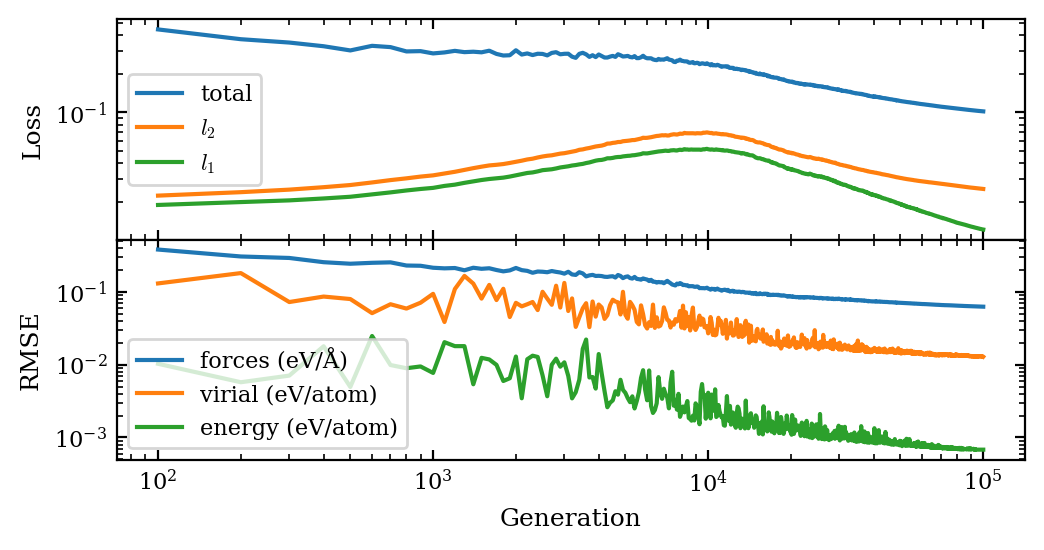

In [3]:
fig = NEP.plot_loss()
#fig.savefig('figures/Loss_and_RMSE.pdf', bbox_inches='tight')

We can also inspect predicted vs target values for energy, force, viral and stress.

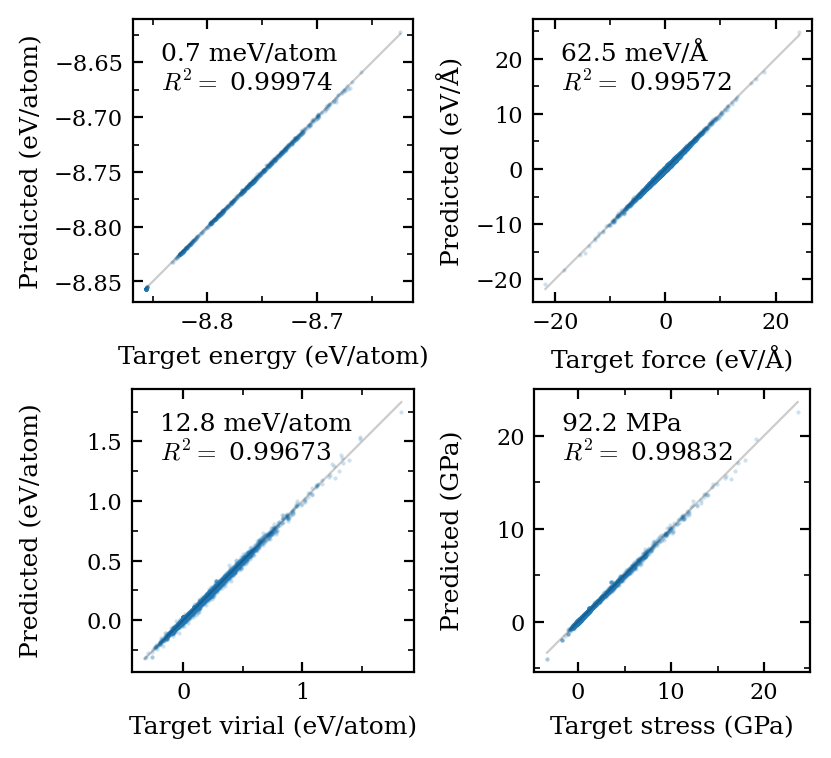

In [4]:
fig = NEP.plot_parity()
#fig.savefig('figures/parity.pdf', bbox_inches='tight')

### 3. Build active set

With the NEP model trained, we need to build an active set to calculate extrapolation grades.

In [52]:
# Build Active Set (.asi) with MaxVol
NEP.build_active_set()

Building active set...
Calculating descriptors for 128 structures...


100%|██████████| 128/128 [00:05<00:00, 24.38it/s]


Building active set for Ba...
Maxvol Speed: 16741 iters/s
Building active set for O...
Maxvol Speed: 2844 iters/s
Building active set for Ti...
Maxvol Speed: 8513 iters/s
Active set inverse saved to results/ALnep3/iteration_3/active_set.asi
Active set structure saved to results/ALnep3/iteration_3/active_set.xyz


In [ ]:
#view(NEP.active_set_struct)

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/images.py:97: UserWarning: Not all images have the same boundary conditions!
  warnings.warn('Not all images have the same boundary conditions!')
Traceback (most recent call last):
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 34, in <module>
    main()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 30, in main
    plt.show()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/matplotlib/pyplot.py", line 613, in show
    return _get_backend_mod().show(*args, **kwargs)
  File "/home/tbrav/miniconda3/envs/siesta-env

Now that we have the active set, we can calculate the extrapolation grade of all atoms.

In [3]:
NEP.assign_gamma(NEP.train_iter)

Calculating descriptors for 776 structures...


100%|██████████| 776/776 [00:32<00:00, 23.61it/s]


Gamma range: 0.1956 - 1.0


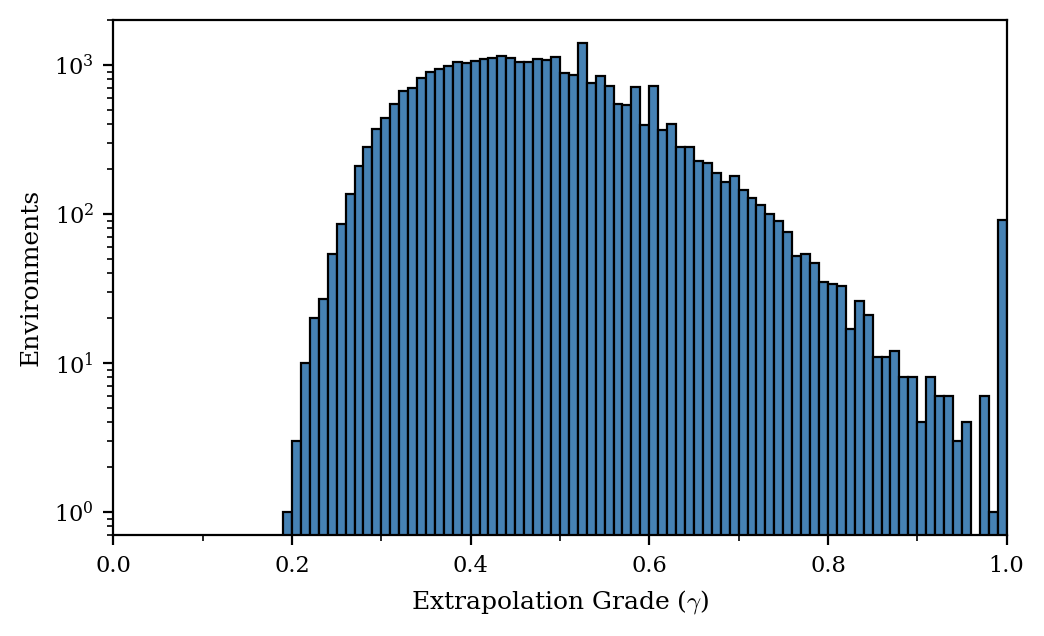

In [7]:
fig = NEP.plot_gamma_model(NEP.train_iter, per_struct=False)

As expected, all structures have extrapolation bellow 1.

We now investigate strained structures

In [48]:
# Apply some strain to the active set structures and re-assign gamma to see how the extrapolation grade changes
NEP.build_active_set()
for atoms in NEP.active_set_struct:
    NEP._strain_structure(atoms, 5)


Existing active set inverse (.asi) and structures (.xyz) found. Loading...


Calculating descriptors for 68 structures...


100%|██████████| 68/68 [00:01<00:00, 49.76it/s]


Gamma range: 0.23154 - 1.85368


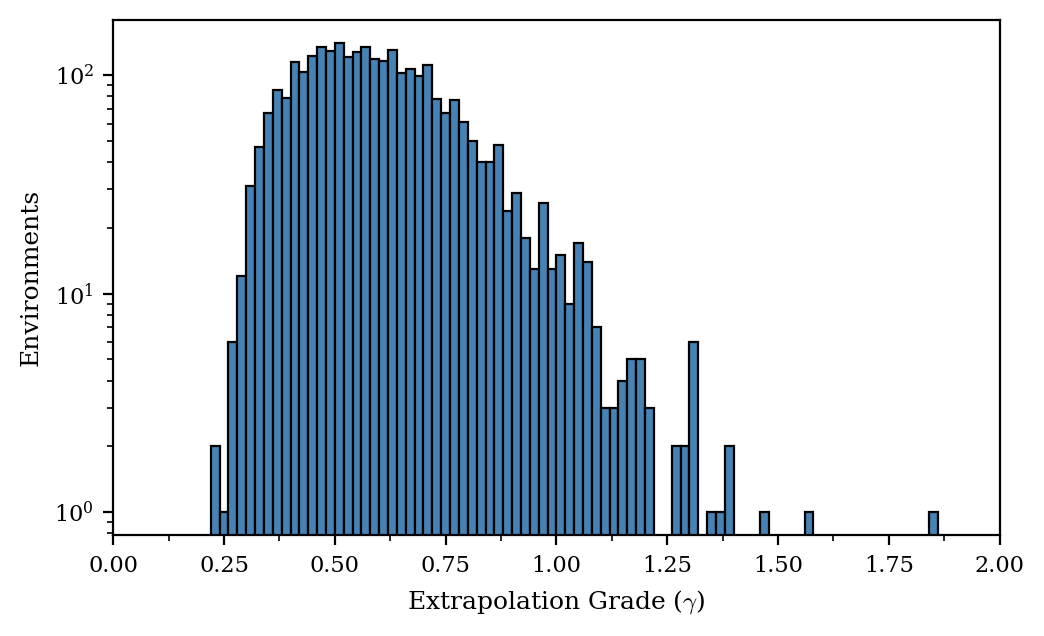

In [49]:
NEP.assign_gamma(NEP.active_set_struct)
plot_gamma_model(NEP.active_set_struct, per_struct=False)

We can now test how resilient the dataset is to larger supercells/systems.

In [ ]:
#sc_structures = [NEP.train_run[i].repeat((2, 2, 1)) for i in range(len(NEP.train_run))]

In [ ]:
NEP.assign_gamma(sc_structures)

All structures already have descriptors calculated.


Gamma range: 0.60647 - 1.74285


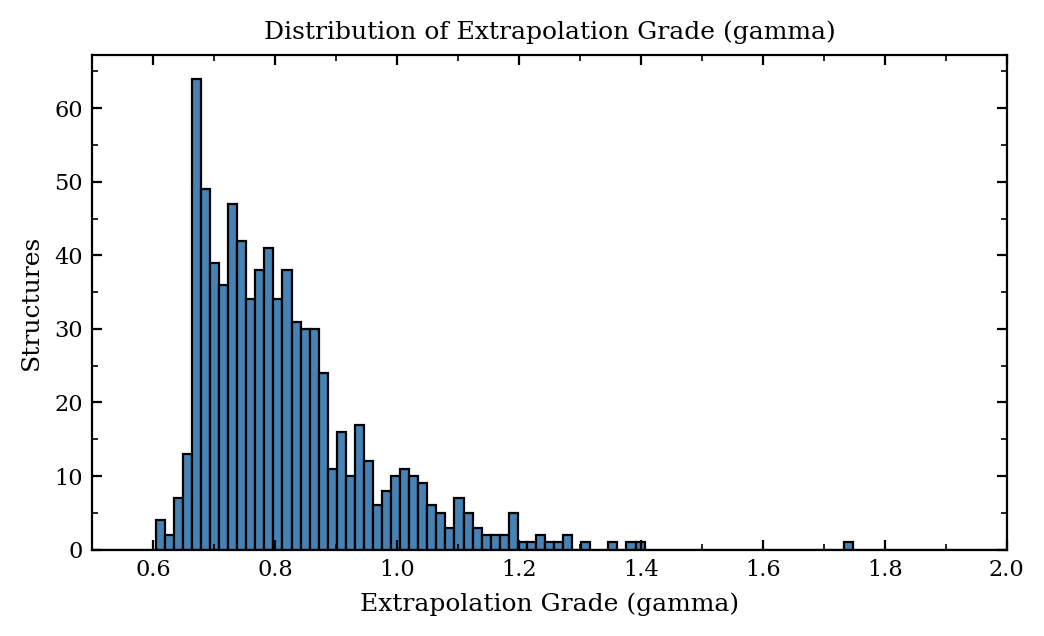

In [ ]:
plot_gamma_model(sc_structures)

These are all bellow 2, so considered a safe extrapolation.

What if we try to make thicker slabs than the model has been trained on?

In [ ]:
from src.structure import Perovskite
slab_structures = [Perovskite('BaTiO3', bulk=False, dslab=(1.5+i)).atoms.repeat((2, 2, 1)) for i in range(2, 20)]

In [ ]:
slab_descriptors = NEP._calculate_descriptors(slab_structures)

Computed descriptor matrix: (4356, 30)


Gamma range: 2.06887 - 2.06887


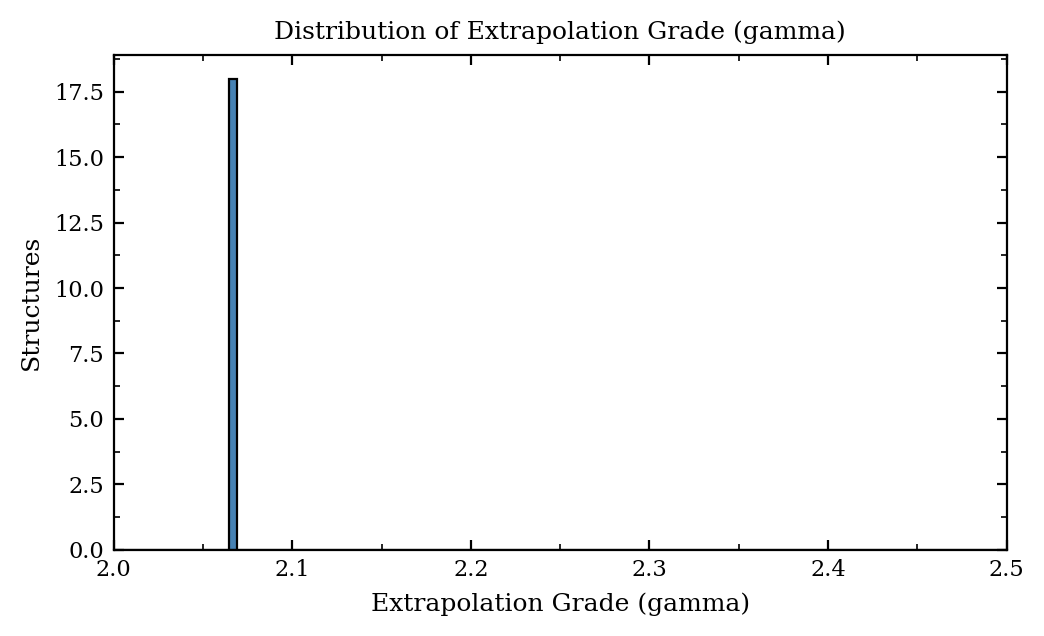

In [ ]:
NEP.assign_gamma(slab_structures, slab_descriptors)
plot_gamma_model(slab_structures)

Does not change at all. Note strain on lattice, should use relaxed slabs for lower gamma.

Now additional phonon ratteling.

In [51]:
import phonopy as ph
from src.phononASE import phonon_to_atoms
phonon = ph.load('results/ALnep/bulk.yaml')

# Produce the force constants
phonon.produce_force_constants()
# Get the force constants matrix
fc = phonon.force_constants

# Convert the phonon object to an ASE Atoms object
atoms = phonon_to_atoms(phonon, cell='super')
rattled_structures = NEP._get_rattled_structures(atoms, fc, 500, 1000)

Acoustic sum rules not enforced, squared frequencies: [0.00482294 0.00485357 0.00488422]
Imaginary modes present


Calculating descriptors for 1000 structures...


100%|██████████| 1000/1000 [00:38<00:00, 25.69it/s]


Gamma range: 0.70159 - 1.93261


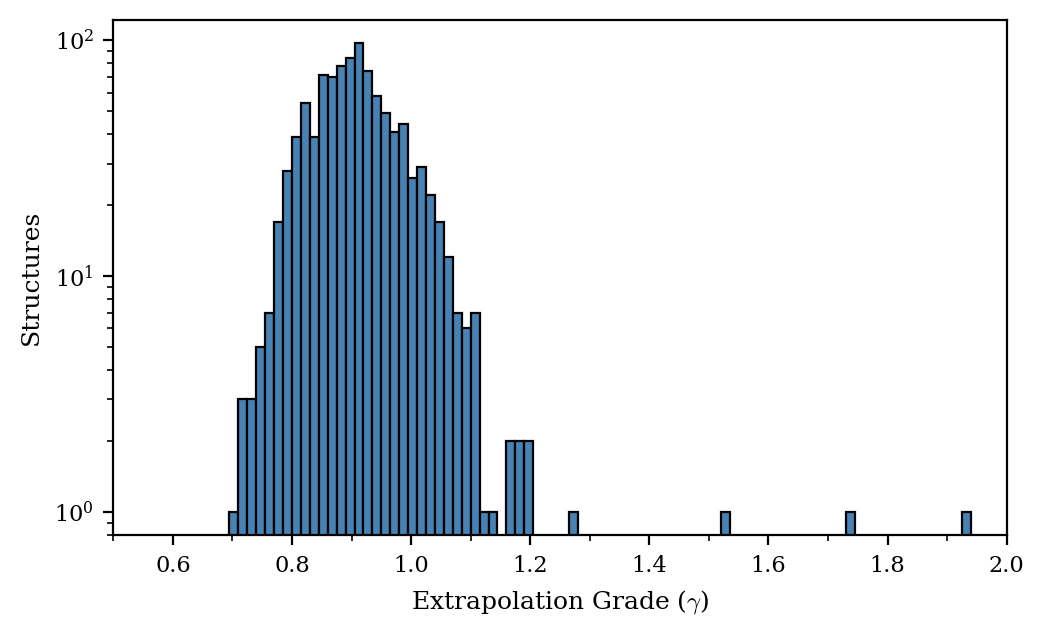

In [52]:
NEP.assign_gamma(rattled_structures)
plot_gamma_model(rattled_structures)

### 4. MD exploration

We now run MD to explore for new configurations that have high extrapolation grade.

In [ ]:
# Set up MD exploration
NEP.setup_MD_exploration(dt=1, n_steps=1*1e6, n_dump=1000, Tmax=600)
#NEP.run_MD()       # run on HPC GPU node (surt.fysik.dtu.dk or sara.fysik.dtu.dk)

In [3]:
NEP.collect_MD_structures()

In [9]:
md_structures = read(os.path.join(NEP.iter_dir, 'md/md_structures.xyz'), index=':')

In [4]:
md_structures = md_structures[::2]

In [10]:
len(md_structures)

6000

In [11]:
view(md_structures)

<Popen: returncode: None args: ['/home/tbrav/projects/OxideSlabs2/.venv/bin/...>

/home/tbrav/projects/OxideSlabs2/.venv/lib/python3.10/site-packages/ase/gui/images.py:97: UserWarning: Not all images have the same boundary conditions!
  warnings.warn('Not all images have the same boundary conditions!')
Traceback (most recent call last):
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/tbrav/projects/OxideSlabs2/.venv/lib/python3.10/site-packages/ase/gui/pipe.py", line 34, in <module>
    main()
  File "/home/tbrav/projects/OxideSlabs2/.venv/lib/python3.10/site-packages/ase/gui/pipe.py", line 30, in main
    plt.show()
  File "/home/tbrav/projects/OxideSlabs2/.venv/lib/python3.10/site-packages/matplotlib/pyplot.py", line 613, in show
    return _get_backend_mod().show(*args, **kwargs)
  File "/home/tbrav/projects/OxideSlabs2/.venv

In [ ]:
#md_structures = []

#for label in ['Ba4O20Ti8', 'Ba8O24Ti8', 'Ba8O32Ti12']:
#    structures = read(f'results/ALnep3/iteration_1/md_exploration/{label}/600K/dump.xyz', index=':')
    # Downsize and take every 10th structure to reduce the number of structures for DFT calculations
#    write(f'results/ALnep3/iteration_1/md_exploration/{label}/600K/dump.xyz', structures[::10])

In [ ]:
"""
md_structures = []
for label in ['Ba4O20Ti8', 'Ba8O24Ti8', 'Ba8O32Ti12']:
    structures = read(f'results/ALnep3/iteration_1/md_exploration/{label}/600K/dump.xyz', index=':')
    md_structures.extend(structures)
"""

In [6]:
NEP.assign_gamma(md_structures)

Calculating descriptors for 6000 structures...


100%|██████████| 6000/6000 [03:59<00:00, 25.04it/s]


In [8]:
test = [struct for struct in md_structures if max(struct.arrays["gamma"]) > 1.001]

In [9]:
len(test)

110

In [ ]:
view(test)

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/images.py:97: UserWarning: Not all images have the same boundary conditions!
  warnings.warn('Not all images have the same boundary conditions!')


In [80]:
len(test)

1364

In [81]:
view(test)

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/images.py:97: UserWarning: Not all images have the same boundary conditions!
  warnings.warn('Not all images have the same boundary conditions!')
Traceback (most recent call last):
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 34, in <module>
    main()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 30, in main
    plt.show()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/matplotlib/pyplot.py", line 613, in show
    return _get_backend_mod().show(*args, **kwargs)
  File "/home/tbrav/miniconda3/envs/siesta-env

Gamma range: 0.62856 - 1.66242


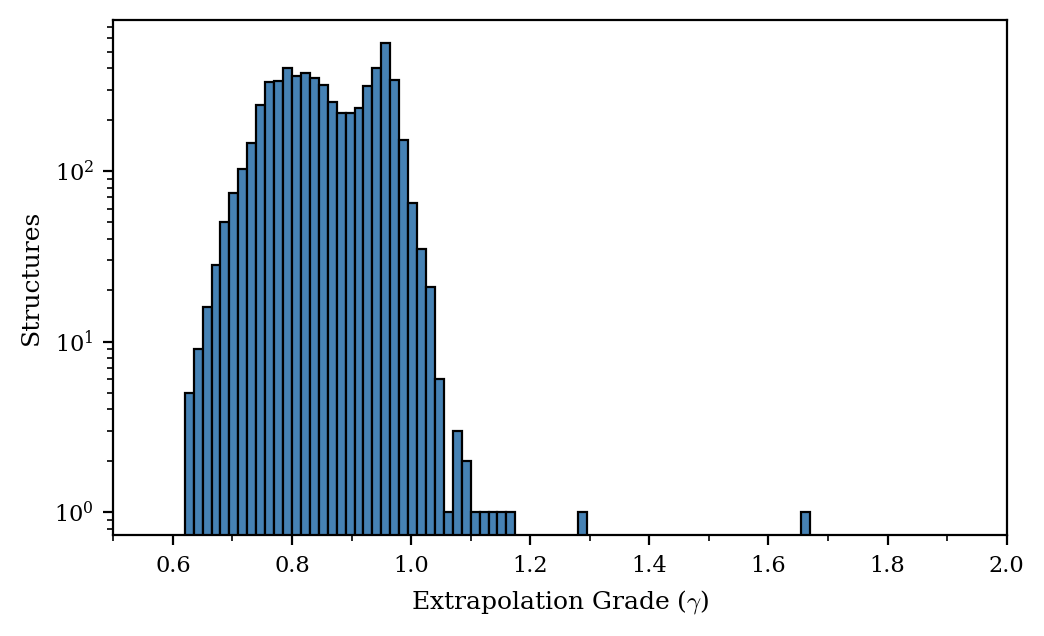

In [7]:
fig = NEP.plot_gamma_model(md_structures, per_struct=True)

In [61]:
# Collect structure from different MD runs
#NEP.collect_MD_structures()
md_structures = []
for temp in ['100K', '200K', '300K', '400K', '500K', '600K']:
    md_structures.extend(read(os.path.join(NEP.iter_dir, f'md_old4/Ba4O20Ti8/{temp}/dump.xyz'), ':'))
#md_structures
#md_test = md_test[-1000:]

In [13]:
md_structures = read(os.path.join(NEP.iter_dir, 'md/md_structures.xyz'), index=':')

In [14]:
from ase.visualize import view
view(md_structures)

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/images.py:97: UserWarning: Not all images have the same boundary conditions!
  warnings.warn('Not all images have the same boundary conditions!')
Traceback (most recent call last):
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 34, in <module>
    main()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/ase/gui/pipe.py", line 30, in main
    plt.show()
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/site-packages/matplotlib/pyplot.py", line 613, in show
    return _get_backend_mod().show(*args, **kwargs)
  File "/home/tbrav/miniconda3/envs/siesta-env

All structures already have descriptors calculated.
Gamma range: 0.16734 - 1.2903


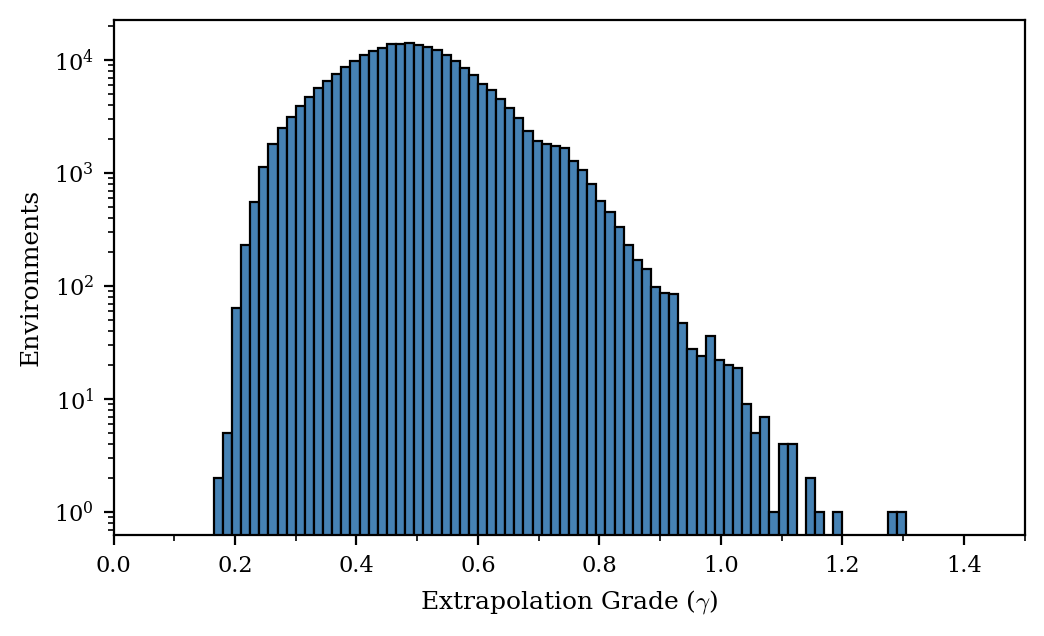

In [9]:
NEP.assign_gamma(md_structures)
plot_gamma_model(md_structures, per_struct=False)

In [ ]:
#from src.structure import wrap_to_reference
def wrap_continuous(traj, ref_atoms):
    wrapped = []

    #prev = ref_atoms.copy()
    #wrapped.append(prev)

    #cell = ref_atoms.get_cell()
    ref_scaled = ref_atoms.get_scaled_positions()

    for atoms in traj:
        new_atoms = atoms.copy()

        scaled = atoms.get_scaled_positions()

        delta = scaled - ref_scaled
        delta -= np.floor(delta + 0.5)  # wrap into [-0.5, 0.5]

        new_scaled = ref_scaled + delta

        new_atoms.set_scaled_positions(new_scaled)

        wrapped.append(new_atoms)

        # update reference
        ref_scaled = new_scaled

    return wrapped

<Popen: returncode: None args: ['/home/tbrav/miniconda3/envs/siesta-env/bin/...>

### 5. Structure filtering

To not consider all structures obtained from MD, we can calculate extrapolation grade and filter.

All structures containing no atoms/environments with gamma > gamma_th are removed.

In [22]:
#md_structures = read(os.path.join(NEP.iter_dir, 'md/md_structures.xyz'), index=':')

In [11]:
md_structures = read(os.path.join(NEP.iter_dir, 'md_exploration/md_structures.xyz'), index=':')

In [17]:
NEP.iter_dir

'results/ALnep3/iteration_3'

In [ ]:
view(md_structures)

<Popen: returncode: None args: ['/home/tbrav/projects/OxideSlabs2/.venv/bin/...>

/home/tbrav/projects/OxideSlabs2/.venv/lib/python3.10/site-packages/ase/gui/images.py:97: UserWarning: Not all images have the same boundary conditions!
  warnings.warn('Not all images have the same boundary conditions!')


Calculating descriptors for 12000 structures...


  0%|          | 0/12000 [00:00<?, ?it/s]

100%|██████████| 12000/12000 [05:59<00:00, 33.41it/s]


Gamma range: 0.62228 - 2.01217


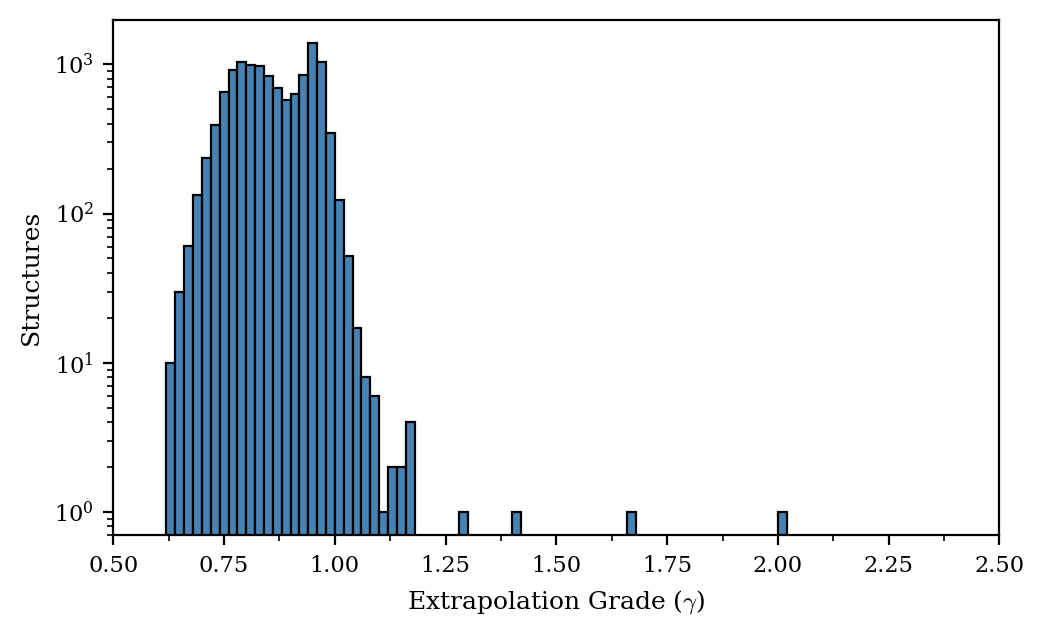

In [13]:
NEP.assign_gamma(md_structures)
fig = NEP.plot_gamma_model(md_structures, per_struct=True)

In [16]:
view([struct for struct in md_structures if max(struct.arrays["gamma"]) > 1.2])

<Popen: returncode: None args: ['/home/tbrav/projects/OxideSlabs2/.venv/bin/...>

In [11]:
# Load the collected structures and filter them based on the gamma threshold
#structures = read(os.path.join(NEP.iter_dir, "md/md_structures.xyz"), index=":")
NEP.filter_structures(md_structures, gamma_th=1.001)

Filtering out structures with gamma < 1.001...
Calculating descriptors for structures...


All structures already have gamma values.
Found 110 structures with gamma > 1.001.


### 6. Diversity selection

Since we do not wish to perform DFT on all high-gamma structures, diversity selection is performed.

This ensures that only structures with atoms contributing with new basis vectors in the active set are included.

By doing this, only the most diverse environments are included.

In [20]:
# Read high gamma structures and select based on diversity (MaxVol)
structures = read(os.path.join(NEP.iter_dir, "large_gamma.xyz"), index=":")
#len(structures)
NEP.select_structures(structures)

Performing diversity selection with MaxVol
Calculating descriptors for 128 structures...


100%|██████████| 128/128 [00:07<00:00, 17.13it/s]


Building active set for Ba...
Maxvol Speed: 2803 iters/s
Building active set for O...
Maxvol Speed: 1453 iters/s
Building active set for Ti...
Maxvol Speed: 4580 iters/s
Found 2 filtered structures.


In [3]:
selected_structures = read(os.path.join(NEP.iter_dir, "newdata.xyz"), index=':')

In [ ]:
view(selected_structures)

<Popen: returncode: None args: ['/home/tbrav/projects/OxideSlabs2/.venv/bin/...>

/home/tbrav/projects/OxideSlabs2/.venv/lib/python3.10/site-packages/ase/gui/images.py:97: UserWarning: Not all images have the same boundary conditions!
  warnings.warn('Not all images have the same boundary conditions!')


In [4]:
len(selected_structures)

2

In [5]:
NEP.update_dataset()

Sucessfully added 2 structures to train.xyz
Total structures in train.xyz: 130


### Results

In [95]:
NEP = ActiveLearningNEP('results/ALnep')

Current iteration: 2


Loaded 838 training structures and 84 test structures
All structures have calculator results.
Existing NEP model found. Loading...
Existing active set inverse (.asi) and structures (.xyz) found. Loading...


In [96]:
# List folders in NEP.run_dir
iter_folders = [f for f in os.listdir(NEP.run_dir) if os.path.isdir(os.path.join(NEP.run_dir, f))]
# Remove 'DFT' from the list if it exists
iter_folders = [f for f in iter_folders if f != 'DFT']

In [55]:
iter_folders = iter_folders[:3]

In [97]:
iters = np.arange(len(iter_folders))

In [ ]:
# Calorine
from calorine.nep import get_descriptors, get_parity_data, read_loss, read_structures
from calorine.calculators import CPUNEP
from calorine.tools import get_force_constants
from hiphive.structure_generation import generate_phonon_rattled_structures
# Sklearn
from sklearn.metrics import r2_score, mean_squared_error

units = dict(
        energy='eV/atom',
        force='eV/Å',
        virial='eV/atom',
        stress='GPa',
    )

N_train = []
N_env = []
dF_RMSE = []
dF_max = []
#rmses = {prop: [] for prop in units.keys()}
#R2s = {prop: [] for prop in units.keys()}

for iter_folder in iter_folders:

    training_structures, _ = read_structures(os.path.join(NEP.run_dir, iter_folder, 'nep'))
    N_train.append(len(training_structures))
    # Count total number of atoms in the training structures
    N_env.append(sum(len(struct) for struct in training_structures))

    df = get_parity_data(training_structures, 'force', flatten=True)
    dF_RMSE.append(np.sqrt(mean_squared_error(df.target, df.predicted)))
    dF_max.append(np.max(np.abs(df.target - df.predicted)))
    """
    # Loop over the properties and units, get the parity data, calculate R2 and RMSE
    for icol, (prop, unit) in enumerate(units.items()):
        df = get_parity_data(training_structures, prop, flatten=True)
        R2 = r2_score(df.target, df.predicted)
        rmse = np.sqrt(mean_squared_error(df.target, df.predicted))
        rmses[prop].append(rmse)
        R2s[prop].append(R2)
    """

    #NEP = ActiveLearningNEP('results/ALnep3', iteration=i+1)

    #N = len(NEP.train_run)
    #print(f"{iter}: {N} training structures")

N_train = np.array(N_train)
N_env = np.array(N_env)
dF_RMSE = np.array(dF_RMSE)
dF_max = np.array(dF_max)

"\naxes[1].plot(iters, np.array(rmses['energy'])*1e3)\naxes[1].set_ylabel('Energy RMSE (meV/atom)')\n\naxes[2].plot(iters, np.array(rmses['force'])*1e3)\naxes[2].set_ylabel('Force RMSE (meV/Å)')\n\naxes[4].set_xlabel('Active learning generation')\naxes[4].set_xlim(0, max(iters))\n"

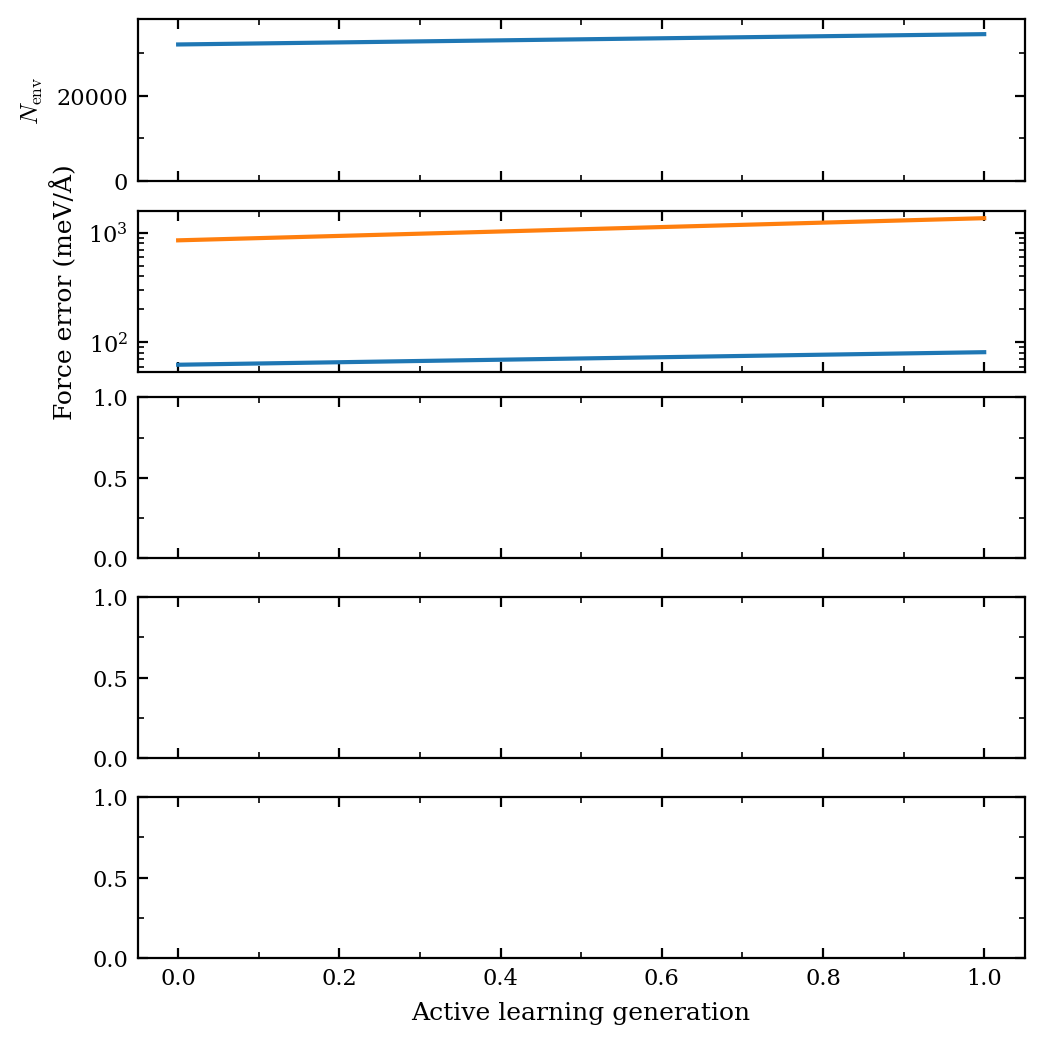

In [103]:
# Plot the learning curves for each property vs iteration number
lf = LatexFigure()
fig, axes = lf.create(AR=0.2, width=1, subplots=(5, 1), sharex=True)

"""
axes[0].plot(iters, N_train)
axes[0].set_ylabel('$N_\mathrm{train}$')
axes[0].set_ylim(0, max(N_train)*1.1)
"""
axes[0].plot(iters, N_env)
axes[0].set_ylabel('$N_\mathrm{env}$')
axes[0].set_ylim(0, max(N_env)*1.1)

axes[1].plot(iters, dF_RMSE*1e3)
axes[1].plot(iters, dF_max*1e3)
axes[1].set_ylabel('Force error (meV/Å)')
axes[1].set_yscale('log')
#axes[1].set_ylim(1e2, 1e4)

axes[-1].set_xlabel('Active learning generation')

"""
axes[1].plot(iters, np.array(rmses['energy'])*1e3)
axes[1].set_ylabel('Energy RMSE (meV/atom)')

axes[2].plot(iters, np.array(rmses['force'])*1e3)
axes[2].set_ylabel('Force RMSE (meV/Å)')

axes[4].set_xlabel('Active learning generation')
axes[4].set_xlim(0, max(iters))
"""

In [50]:
iter_folders

['iteration_1', 'iteration_2', 'iteration_3', 'iteration_4']

In [ ]:
def calculate_dE_dF(structures):
    from calorine.calculators import CPUNEP

    for structure in structures:
        try:
            E_DFT = structure.get_potential_energy()
            F_DFT = structure.get_forces().copy()
        except RuntimeError:
            continue
        calc = CPUNEP(NEP.nep_txt)
        atoms = structure.copy()
        N_atoms = len(atoms)
        atoms.calc = calc
        E_ML = atoms.get_potential_energy()
        F_ML = atoms.get_forces()

        # Calculate energy error per structure
        dE = np.abs(E_DFT - E_ML)
        structure.info["dE"] = dE/N_atoms

        # Calculate the norm of the force error per structure
        dF = np.linalg.norm(F_DFT - F_ML, axis=1)
        structure.arrays["dF"] = dF

In [86]:
calculate_dE_dF(structures)

In [ ]:
def plot_dE_dF_gamma(structures, per_struct=False):
    dE = np.array([struct.info["dE"]*1e3 for struct in structures])
    gamma_E = np.array([max(struct.arrays["gamma"]) for struct in structures])

    if per_struct:
        gamma_F = gamma_E
        dF = np.array([max(struct.arrays["dF"]) for struct in structures])
    else:
        gamma_F = np.array([gamma for struct in structures for gamma in struct.arrays["gamma"]])
        dF = np.array([dF for struct in structures for dF in struct.arrays["dF"]])

    lf = LatexFigure()
    fig, axes = lf.create(subplots=(1, 2))

    # Subplot 1: dE vs gamma
    ax = axes[0]
    ax.scatter(gamma_E, dE, alpha=0.5, s=10, color='steelblue', lw=0.8)
    # Plot dashed line at gamma = 1
    ax.axvline(1, color='k', linestyle='--', lw=0.8)
    ax.set_xlabel('$\\gamma$ (per structure)')
    ax.set_ylabel('|dE| (meV/atom)')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(1e-1, 1e1)

    # Subplot 2: dF vs gamma
    ax = axes[1]
    ax.scatter(gamma_F, dF, alpha=0.5, s=10, color='steelblue', lw=0.8)
    # Plot dashed line at gamma = 1
    ax.axvline(1, color='k', linestyle='--', lw=0.8)
    ax.set_xlabel('$\\gamma$ (per structure)' if per_struct else '$\\gamma$ (per atom)')
    ax.set_ylabel('|dF| (eV/Å)')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(1e-1, 1e1)

    return fig

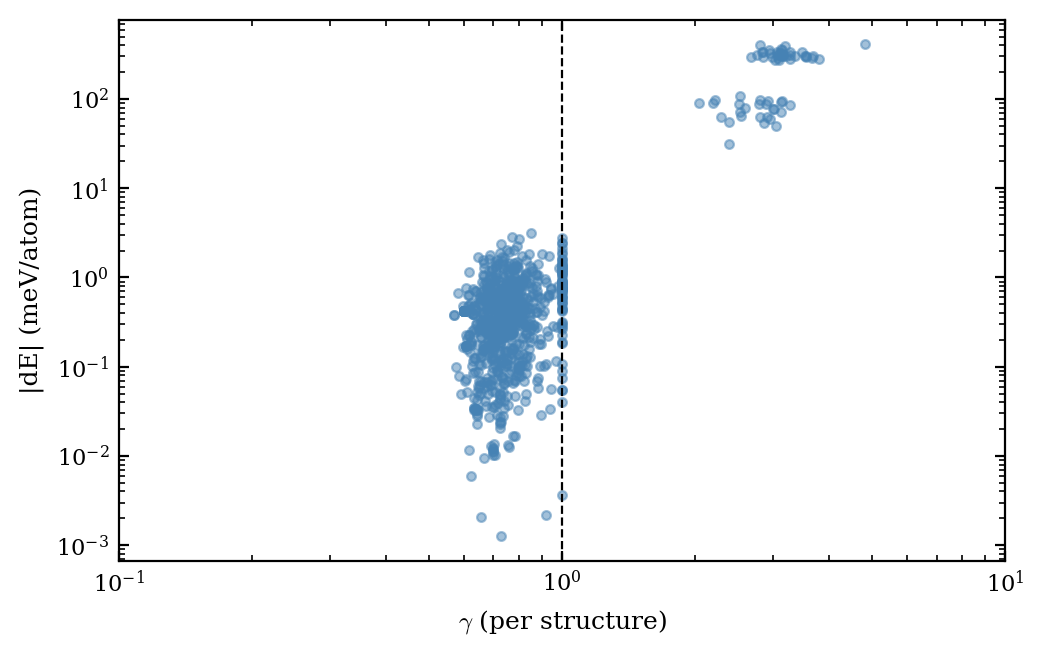

In [ ]:
plot_dE_dF_gamma(structures)

## Model predictions

### Phonon dispersions

In [7]:
from ase.io import read
from calorine.calculators import CPUNEP
from calorine.tools import relax_structure, get_force_constants
from src.structure import Perovskite
from src.phononcalc import plot_dispersion

In [10]:
from src.activeNEP import ActiveLearningNEP
NEP = ActiveLearningNEP('results/ALnep')

Current iteration: 2
Loaded 838 training structures and 84 test structures
All structures have calculator results.
Existing NEP model found. Loading...
Existing active set inverse (.asi) and structures (.xyz) found. Loading...


      Step     Time          Energy          fmax
BFGS:    0 09:57:23      -44.270154        0.290011
BFGS:    1 09:57:23      -44.273502        0.248689
BFGS:    2 09:57:24      -44.282691        0.004178
BFGS:    3 09:57:24      -44.282694        0.000058


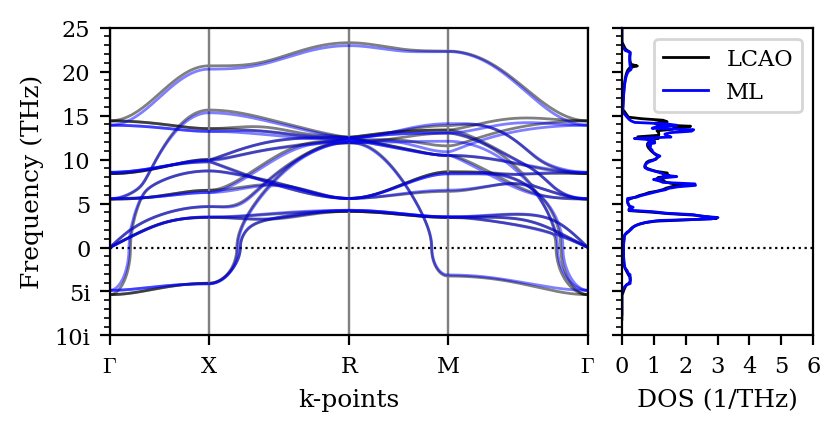

In [11]:
# Calculate phonons for the bulk unit cell structure using the trained NEP model
perovskite_bulk = Perovskite('BaTiO3')
atoms = perovskite_bulk.atoms.copy()
NEP.relax_atoms(atoms)
phonon_ML = NEP.calculate_phonon(atoms)
# Load the phonon DFT calculation results from the YAML file
phonon_LCAO = phonopy.load("results/bulk/BaTiO3/0082/phonons/BaTiO3.yaml")
fig = plot_dispersion([phonon_LCAO, phonon_ML], ['LCAO', 'ML'], width=0.8)

In [ ]:
"""
strains = np.linspace(-0.01, 0.01, 5)

phonons = []
for strain in strains:
    perovskite.set_atoms(atoms)
    perovskite.apply_strain(strain)
    if strain != 0:
        NEP.relax_atoms(perovskite.atoms, strained=True)
    else:
        NEP.relax_atoms(perovskite.atoms)
    phonon = NEP.calculate_phonon(perovskite.atoms)
    phonons.append(phonon)
"""

      Step     Time          Energy          fmax
BFGS:    0 13:45:19      -44.260969        0.184184
BFGS:    1 13:45:19      -44.261430        0.166383
BFGS:    2 13:45:20      -44.263489        0.001513
BFGS:    3 13:45:20      -44.263489        0.000012
      Step     Time          Energy          fmax
BFGS:    0 13:45:20      -44.277331        0.090975
BFGS:    1 13:45:20      -44.277443        0.082236
BFGS:    2 13:45:20      -44.277948        0.000381
BFGS:    3 13:45:20      -44.277948        0.000002
      Step     Time          Energy          fmax
BFGS:    0 13:45:20      -44.282694        0.000058
      Step     Time          Energy          fmax
BFGS:    0 13:45:20      -44.277456        0.088855
BFGS:    1 13:45:20      -44.277563        0.080430
BFGS:    2 13:45:20      -44.278049        0.000387
BFGS:    3 13:45:20      -44.278049        0.000002
      Step     Time          Energy          fmax
BFGS:    0 13:45:20      -44.262005        0.175364
BFGS:    1 13:45:20   

In [96]:
#fig = plot_dispersion(phonons, ['-0.01', '-0.005', '0.0', '0.005', '0.01'], width=0.8)

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from src.frozenphonon import get_displacement, get_unstable_mode_groups
from src.phononASE import phonon_to_atoms

# Double well potential
# ---------- Models ----------

def U_anharm(x, a, b):
    return -0.5 * a * x**2 + 0.25 * b * x**4


# ---------- Utilities ----------

def symmetrize_data(x, y):
    x_sym = np.concatenate((-x[::-1], x))
    y_sym = np.concatenate((y[::-1], y))
    return x_sym, y_sym


def extract_dw_properties(a, b):
    x0 = np.sqrt(a / b)
    barrier = a**2 / (4 * b)
    return x0, barrier


def fit_double_well(x, y):
    x, y = symmetrize_data(x, y)

    # Shift minimum to zero reference
    y = y - y[np.argmin(np.abs(x))]

    popt, _ = curve_fit(
        U_anharm,
        x,
        y,
        bounds=([0, 0], [np.inf, np.inf])
    )

    a, b = popt
    xfit = np.linspace(min(x), max(x), 1000)
    yfit = U_anharm(xfit, a, b)

    x0, barrier = extract_dw_properties(a, b)

    return x, y, xfit, yfit, x0, barrier

def displace_imaginary_modes(phonon, n_points=101, deg=True):
    """
    """
    # Get current working directory (cwd)
    #cwd = os.getcwd()
    # Unitcell and formula from phonon object
    unitcell = phonon_to_atoms(phonon, cell='unit')
    #formula = unitcell.symbols

    # Dictionary for q-points
    q_dict = {
        'G': [0.0, 0.0, 0.0],
        'X': [0.5, 0.0, 0.0],
        'M': [0.5, 0.5, 0.0],
        'R': [0.5, 0.5, 0.5],
    }

    dd_dict = {
        'G': 0.5/n_points,
        'X': 1.5/n_points,
        'M': 3/n_points,
        'R': 5/n_points,
    }

    results = {}

    for qpoint in q_dict.keys():

        q = q_dict[qpoint]
        dd = dd_dict[qpoint]

        groups, stable = get_unstable_mode_groups(phonon, q)

        if stable:
            print(f"No unstable modes found at {qpoint}")
            continue

        results[qpoint] = {}

        for g_id, group in enumerate(groups):

            modes = group["modes"]
            freq = group["frequency"]

            if not deg:
                modes = [modes[0]]

            results[qpoint][g_id] = {}

            for mode_id, modevec in enumerate(modes):

                modevec_sc, supercell, supercell_matrix = get_displacement(unitcell, q, modevec)

                nx, ny, nz = supercell_matrix.diagonal().astype(int)
                ncells = nx * ny * nz

                calc = CPUNEP(os.path.join(NEP.iter_dir, 'nep.txt'))

                supercell_disp = supercell.copy()
                ref_positions = supercell.positions.copy()
                supercell_disp.calc = calc

                amp = 0
                amplitudes = []
                energies = []
                images = []

                while True:
                    supercell_disp.positions = ref_positions + amp * modevec_sc

                    # Get energy (eV) per atom
                    energy = supercell_disp.get_potential_energy() / len(supercell_disp)

                    amplitudes.append(amp)
                    energies.append(energy)
                    images.append(supercell_disp.copy())

                    amp += dd

                    tol = 100e-3
                    if len(energies) > 1 and energies[-1] - energies[0] > tol:
                        break

                df = pd.DataFrame({
                    'Amplitude': amplitudes,
                    'Energy': energies,
                    'Structure': images
                })
                

                # Find image corresponding to the minimum energy
                min_idx = np.argmin(energies)
                atoms_min = images[min_idx].copy()
                
                x = df["Amplitude"].to_numpy()
                y = df["Energy"].to_numpy() * 1000  # meV

                x, y, xfit, yfit, x0, barrier = fit_double_well(x, y)

                # store everything
                results[qpoint][g_id][mode_id] = {
                    "df": df,
                    "frequency": freq,
                    "barrier": barrier,
                    "structure": atoms_min
                }

    return results


In [5]:
def calculate_results(perovskite, strains):

    atoms_initial = perovskite.atoms.copy()

    atoms_relax = atoms_initial.copy()
    NEP.relax_atoms(atoms_relax)

    results = {strain: {} for strain in strains}

    for strain in strains:
        perovskite.set_atoms(atoms_relax)
        perovskite.apply_strain(strain)

        if strain != 0:
            NEP.relax_atoms(perovskite.atoms, strained=True)
        #else:
            #NEP.relax_atoms(perovskite.atoms)
        
        #latticevecs[qpoint].append(perovskite.atoms.copy().cell.diagonal())

        phonon = NEP.calculate_phonon(perovskite.atoms)
        #phonons.append(phonon)
        results[strain] = displace_imaginary_modes(phonon, n_points=201, deg=False)
    
    perovskite.set_atoms(atoms_initial)
    return results


In [ ]:
"""
N = 3
mirror = False

#lf = LatexFigure()
#fig, axes = lf.create(subplots=(1, N), AR=2, sharey=True, grid=True)
#color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
for strain in strains:
    res = results[strain]
    lf = LatexFigure()
    N = len(res.keys())
    fig, axes = lf.create(subplots=(1, N), AR=2, sharey=True, grid=True)
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

    qpoints = res.keys()

    for i, q in enumerate(qpoints):

        ax = axes[i]
        color_idx = 0

        for g_id, modes in res[q].items():
            for mode_id, data in modes.items():
                df = data["df"]

                x = df["Amplitude"].to_numpy()
                y = df["Energy"].to_numpy() * 1000  # meV

                try:
                    x, y, xfit, yfit, x0, barrier = fit_double_well(x, y)
                except RuntimeError:
                    continue  # skip bad fits

                color = color_cycle[color_idx % len(color_cycle)]
                color_idx += 1

                if mirror:
                    ax.plot(xfit, yfit, '-', color=color)
                else:
                    mask = xfit >= 0
                    ax.plot(xfit[mask], yfit[mask], '-', color=color)

                # Mark origin
                ax.plot(0, 0, 'k.', markersize=4)

                # Annotate physics
                ax.text(
                    0.05,
                    0.9 - 0.1 * color_idx,
                    f"g{g_id} m{mode_id}\n"
                    f"$Q_0$={x0:.2f}\n"
                    f"$\Delta E$={barrier:.1f} meV",
                    transform=ax.transAxes,
                    fontsize=8,
                    color=color
                )

        ax.set_xlabel(r'$Q$ (amu$^{1/2}$Å)')

        if i == 0:
            ax.set_ylabel(r'$\Delta E$ (meV/u.c.)')
    plt.show()
"""

In [20]:
def unpack_results(results, qpoints):
    
    #strains = np.linspace(-0.025, 0.025, 21)

    frequencies = {q: [] for q in qpoints}
    barriers    = {q: [] for q in qpoints}
    structures  = {q: [] for q in qpoints}

    for strain in results.keys():
        res = results[strain]

        #qpoints = res.keys()

        for i, q in enumerate(qpoints):

            #ax = axes[i]
            freqs = []
            bars = []

            try:
                for g_id, modes in res[q].items():
                    for mode_id, data in modes.items():

                        freqs.append(data["frequency"])
                        bars.append(-data["barrier"])
                        #barrier = data["barrier"]
                        #ax.plot(strain, freq, '.', color='k')
            except KeyError:
                freqs = [0]
                bars = [0]
            
            frequencies[q].append(freqs)
            barriers[q].append(bars)
            structures[q].append(data["structure"])

    frequencies = {q: vals for q, vals in frequencies.items() if vals}
    barriers = {q: vals for q, vals in barriers.items() if vals}

    return frequencies, barriers, structures

In [7]:
def plot_imag_freq(strains, y_vals, y_unit='THz', width=0.9):

    N = len(y_vals.keys())

    lf = LatexFigure()
    fig, axes = lf.create(subplots=(1, N), AR=2, width=width, sharey=True, grid=True)
    #fig.set_constrained_layout_pads(wspace=0, w_pad=0)

    def _plot_by_degeneracy(ax, strains, y_vals):

        strains = np.array(strains)

        def _group_by_degeneracy(y_vals):

            y_vals_grouped = []

            for strain, y_val in zip(strains, y_vals):
                if len(y_val) == 1:
                    if strain == 0:
                        # Duplicate
                        pair = [y_val[0], y_val[0]]
                    else:
                        pair = [y_val[0], 0]
                else:
                    pair = y_val

                # optional symmetry flip
                if strain < 0:
                    pair = pair[::-1]

                y_vals_grouped.append(pair)

            return np.array(y_vals_grouped)
        
        try:
            y_vals_grouped = np.array(y_vals)
            if y_unit == 'meV':
                y_vals_grouped = -1*y_vals_grouped

            ax.plot(strains * 100, y_vals_grouped, '-', lw=1, color='red', label='in-plane')
            ax.plot(strains * 100, y_vals_grouped, '.', markersize=2, color='k')
        
        except Exception:
            y_vals_grouped = _group_by_degeneracy(y_vals)
            if y_unit == 'meV':
                y_vals_grouped = -1*y_vals_grouped

            y_lower = y_vals_grouped[:, 0]
            y_upper = y_vals_grouped[:, 1]

            ax.plot(strains * 100, y_lower, '-', lw=1, color='red', label='in-plane')
            ax.plot(strains * 100, y_upper, '-', lw=1, color='blue', label='out-of-plane')
            ax.plot(strains * 100, y_lower, '.', markersize=2, color='k')
            ax.plot(strains * 100, y_upper, '.', markersize=2, color='k')
        
        ax.set_xlim(strains[0] * 100, strains[-1] * 100)
        ax.legend(loc='lower left')

    for i, qpoint in enumerate(y_vals.keys()):
        _plot_by_degeneracy(
            axes[i],
            strains,
            y_vals[qpoint]
        )

        axes[i].set_xlabel('Bi-axial strain (%)')

        if qpoint == 'G':
            axes[i].set_title(f'$\Gamma$ point')
        else:
            axes[i].set_title(f'{qpoint} point')

    if y_unit == 'THz':
        axes[0].set_ylabel('Frequency (THz)')
    elif y_unit == 'meV':
        axes[0].set_ylabel('$\\Delta$ Energy (meV/atom)')
    axes[0].set_ylim(None, -0.03)
    
    return fig

In [135]:
strains = np.linspace(-0.025, 0.025, 21)
perovskite_bulk = Perovskite('BaTiO3')
results_bulk = calculate_results(perovskite_bulk, strains)

      Step     Time          Energy          fmax
BFGS:    0 15:26:36      -44.270154        0.290011
BFGS:    1 15:26:36      -44.273502        0.248689
BFGS:    2 15:26:36      -44.282691        0.004178
BFGS:    3 15:26:36      -44.282694        0.000058
      Step     Time          Energy          fmax
BFGS:    0 15:26:36      -44.142755        0.474232
BFGS:    1 15:26:36      -44.145810        0.427665
BFGS:    2 15:26:36      -44.159461        0.028491
BFGS:    3 15:26:36      -44.159536        0.004972
BFGS:    4 15:26:36      -44.159538        0.000017
No unstable modes found at R
      Step     Time          Energy          fmax
BFGS:    0 15:26:39      -44.169517        0.425409
BFGS:    1 15:26:39      -44.171976        0.383750
BFGS:    2 15:26:39      -44.182908        0.017995
BFGS:    3 15:26:39      -44.182938        0.003338
BFGS:    4 15:26:39      -44.182939        0.000007
No unstable modes found at R
      Step     Time          Energy          fmax
BFGS:    0 15:

In [ ]:
frequencies, barriers, structures = unpack_results(results_bulk, qpoints=['G', 'X', 'M'])

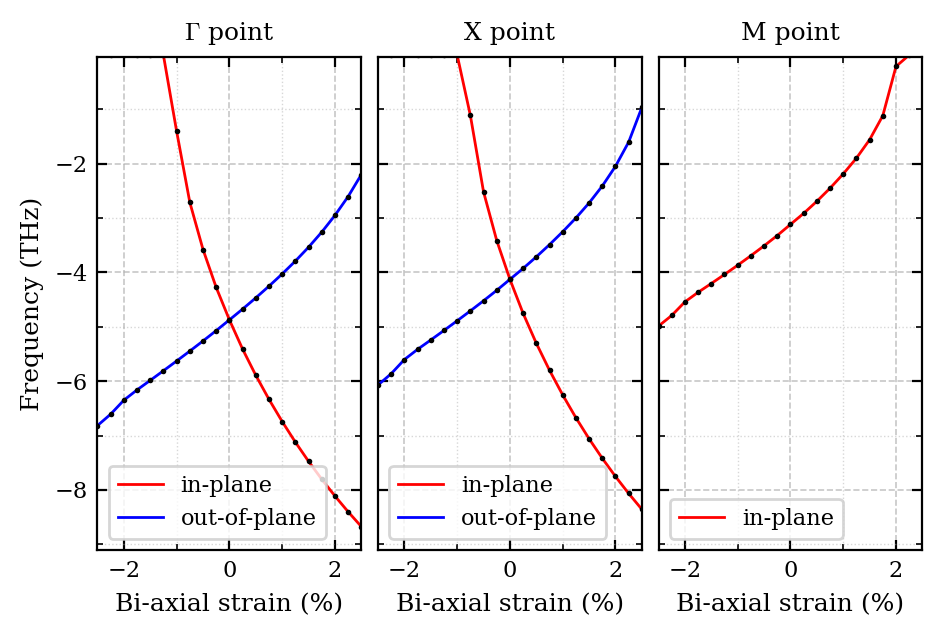

In [ ]:
fig1 = plot_imag_freq(strains, frequencies)
fig1.savefig('figures/NEP_bulk_freq_strain.pdf', bbox_inches='tight')
fig2 = plot_imag_freq(strains, barriers, y_unit='meV')
fig2.savefig('figures/NEP_bulk_dE_strain.pdf', bbox_inches='tight')

In [144]:
indx = np.where(strains == 0)[0][0]
perovskite_bulk = Perovskite('BaTiO3')
perovskite_bulk.set_atoms(structures['G'][indx])
NEP.relax_atoms(perovskite_bulk.atoms, fmax=0.001)

      Step     Time          Energy          fmax
BFGS:    0 15:29:43      -44.286920        0.155548
BFGS:    1 15:29:43      -44.287387        0.139229
BFGS:    2 15:29:43      -44.289267        0.086652
BFGS:    3 15:29:43      -44.289473        0.092754
BFGS:    4 15:29:43      -44.291505        0.091862
BFGS:    5 15:29:43      -44.291850        0.056152
BFGS:    6 15:29:43      -44.292061        0.051058
BFGS:    7 15:29:43      -44.292176        0.030634
BFGS:    8 15:29:43      -44.292269        0.035583
BFGS:    9 15:29:43      -44.292357        0.036609
BFGS:   10 15:29:43      -44.292450        0.037836
BFGS:   11 15:29:43      -44.292701        0.070839
BFGS:   12 15:29:43      -44.292978        0.088056
BFGS:   13 15:29:43      -44.293559        0.086568
BFGS:   14 15:29:43      -44.294598        0.061542
BFGS:   15 15:29:43      -44.294990        0.054565
BFGS:   16 15:29:43      -44.295123        0.061870
BFGS:   17 15:29:43      -44.295303        0.047004
BFGS:   18 15:

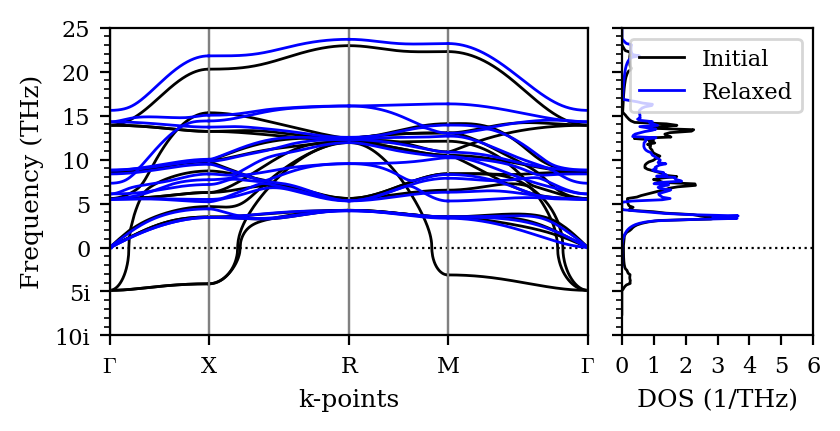

In [145]:
phonon_initial = NEP.calculate_phonon(atoms)
phonon_relaxed = NEP.calculate_phonon(perovskite_bulk.atoms)
fig = plot_dispersion([phonon_initial, phonon_relaxed], ['Initial', 'Relaxed'], width=0.8)

### Slabs

      Step     Time          Energy          fmax
BFGS:    0 16:09:49      -69.803858        2.195412
BFGS:    1 16:09:49      -69.983950        1.471366
BFGS:    2 16:09:49      -70.213438        0.841101
BFGS:    3 16:09:49      -70.250141        0.752768
BFGS:    4 16:09:49      -70.363773        0.092451
BFGS:    5 16:09:49      -70.364745        0.098006
BFGS:    6 16:09:49      -70.366529        0.094474
BFGS:    7 16:09:49      -70.368579        0.074477
BFGS:    8 16:09:49      -70.370868        0.050654
BFGS:    9 16:09:49      -70.371673        0.022330
BFGS:   10 16:09:49      -70.371780        0.003865
BFGS:   11 16:09:49      -70.371785        0.000122
BFGS:   12 16:09:49      -70.371785        0.000020


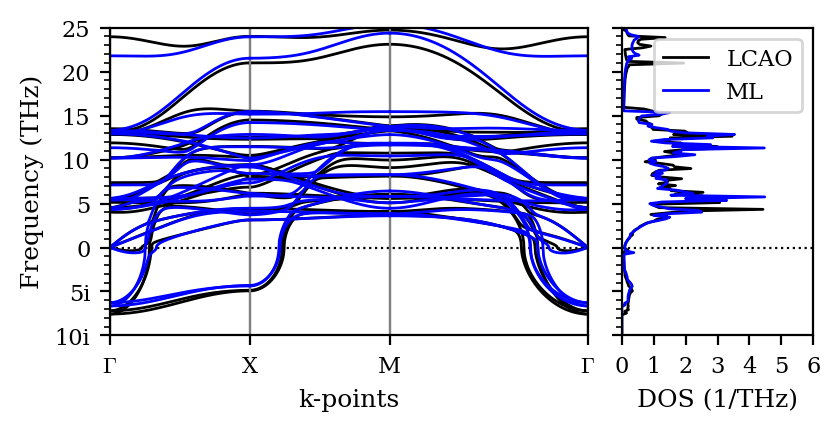

In [8]:
# Calculate phonons for the 1.5 unit cell slab structure using the trained NEP model
perovskite_slab_15 = Perovskite('BaTiO3', bulk=False, dslab=1.5)
atoms_slab_15 = perovskite_slab_15.atoms.copy()
NEP.relax_atoms(atoms_slab_15)
phonon_ML = NEP.calculate_phonon(atoms_slab_15)
# Load the phonon DFT calculation results from the YAML file
phonon_LCAO = phonopy.load("results/slab/BaTiO3/1.5uc/0001/phonons/BaTiO3.yaml")
fig = plot_dispersion([phonon_LCAO, phonon_ML], ['LCAO', 'ML'], width=0.8)

In [21]:
strains = np.linspace(-0.025, 0.025, 21)
perovskite_slab_15 = Perovskite('BaTiO3', bulk=False, dslab=1.5)
results_slab_15 = calculate_results(perovskite_slab_15, strains)

      Step     Time          Energy          fmax
BFGS:    0 16:15:48      -69.803858        2.195412
BFGS:    1 16:15:48      -69.983950        1.471366
BFGS:    2 16:15:48      -70.213438        0.841101
BFGS:    3 16:15:48      -70.250141        0.752768
BFGS:    4 16:15:48      -70.363773        0.092451
BFGS:    5 16:15:48      -70.364745        0.098006
BFGS:    6 16:15:48      -70.366529        0.094474
BFGS:    7 16:15:48      -70.368579        0.074477
BFGS:    8 16:15:48      -70.370868        0.050654
BFGS:    9 16:15:48      -70.371673        0.022330
BFGS:   10 16:15:48      -70.371780        0.003865
BFGS:   11 16:15:48      -70.371785        0.000122
BFGS:   12 16:15:48      -70.371785        0.000020
      Step     Time          Energy          fmax
BFGS:    0 16:15:48      -70.175481        0.217624
BFGS:    1 16:15:48      -70.178093        0.199596
BFGS:    2 16:15:48      -70.194812        0.197372
BFGS:    3 16:15:48      -70.195915        0.149347
BFGS:    4 16:15

In [22]:
frequencies, barriers, structures = unpack_results(results_slab_15, qpoints=['G', 'X'])

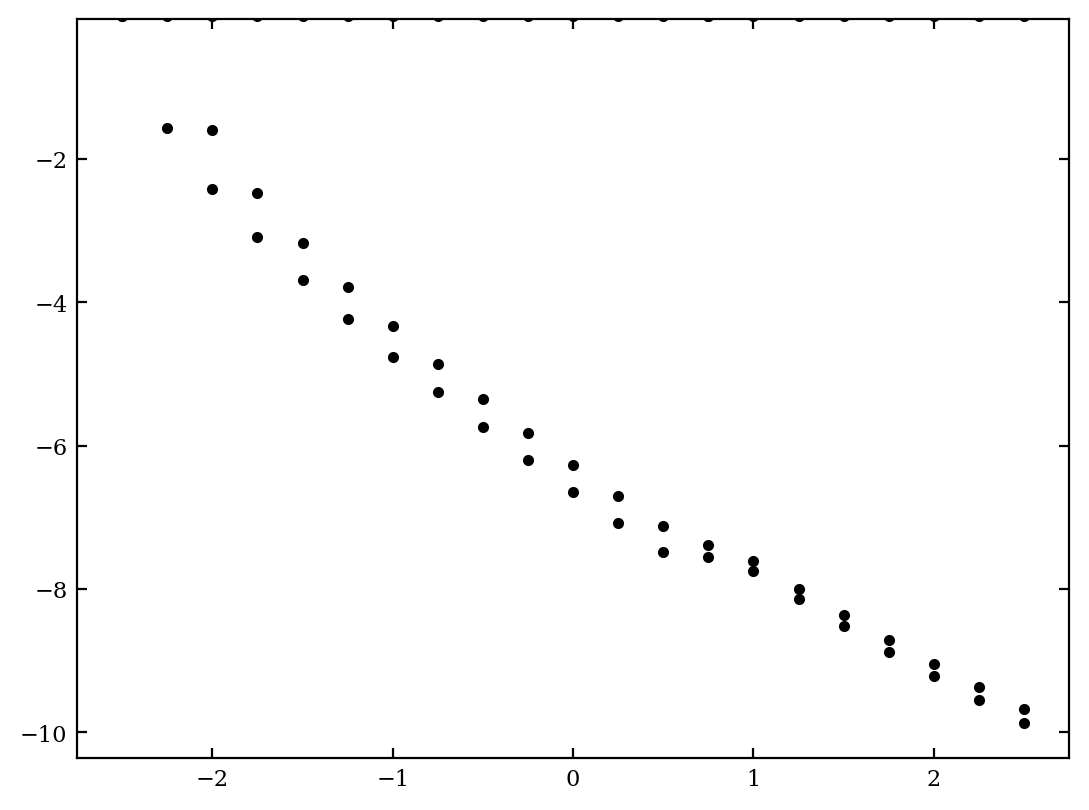

In [23]:
for i, strain in enumerate(strains):
    y = np.array(frequencies['G'][i])
    x = np.ones(len(y)) * strain * 100
    plt.plot(x, y, 'k.')

plt.ylim(None, -0.05)

plt.show()

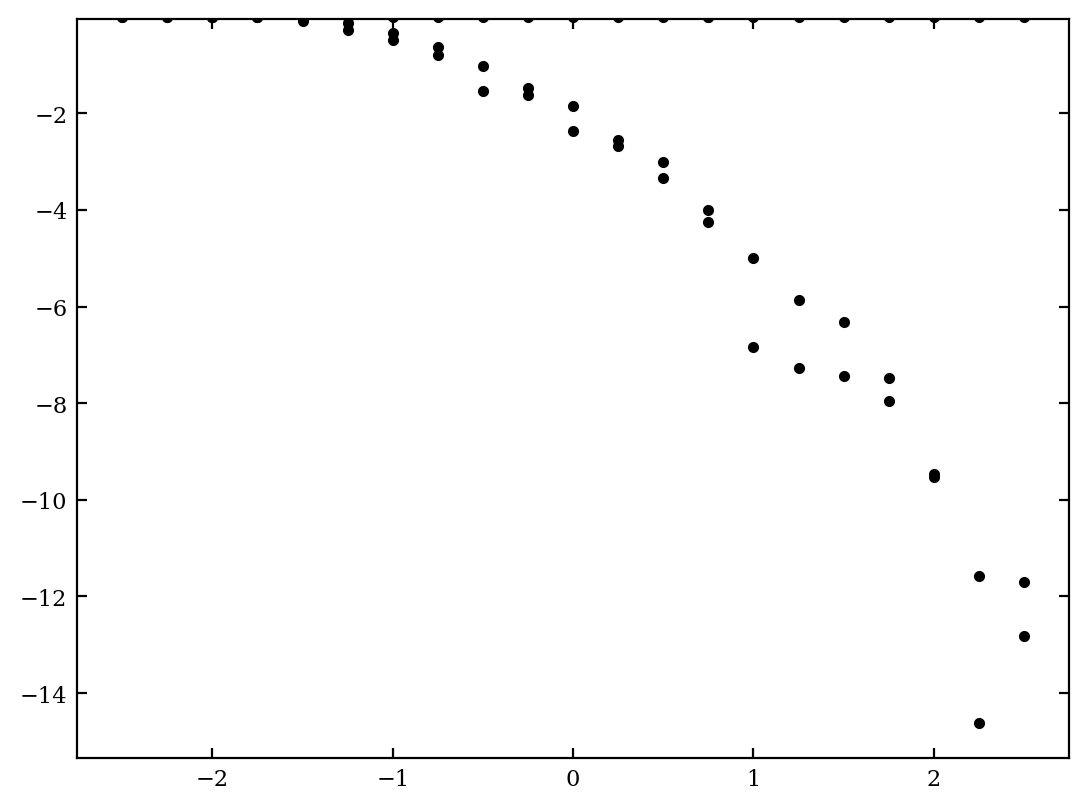

In [29]:
for i, strain in enumerate(strains):
    y = np.array(barriers['G'][i])
    x = np.ones(len(y)) * strain * 100
    plt.plot(x, y, 'k.')

plt.ylim(None, -0.05)

plt.show()

In [48]:
indx = np.where(strains == 0)[0][0]
perovskite_slab_15 = Perovskite('BaTiO3', bulk=False, dslab=1.5)
atoms_initial = perovskite_slab_15.atoms.copy()
NEP.relax_atoms(atoms_initial, fmax=0.001)
#perovskite_slab_15.set_atoms(structures['G'][indx])
atoms_final = structures['G'][indx]
NEP.relax_atoms(atoms_final, fmax=0.001)
#atoms_final = perovskite_slab_15.atoms.copy()

      Step     Time          Energy          fmax
BFGS:    0 16:29:08      -69.803858        2.195412
BFGS:    1 16:29:08      -69.983950        1.471366
BFGS:    2 16:29:08      -70.213438        0.841101
BFGS:    3 16:29:08      -70.250141        0.752768
BFGS:    4 16:29:08      -70.363773        0.092451
BFGS:    5 16:29:08      -70.364745        0.098006
BFGS:    6 16:29:08      -70.366529        0.094474
BFGS:    7 16:29:08      -70.368579        0.074477
BFGS:    8 16:29:08      -70.370868        0.050654
BFGS:    9 16:29:08      -70.371673        0.022330
BFGS:   10 16:29:08      -70.371780        0.003865
BFGS:   11 16:29:08      -70.371785        0.000122
BFGS:   12 16:29:08      -70.371785        0.000020
BFGS:   13 16:29:08      -70.371785        0.000002
BFGS:   14 16:29:08      -70.371785        0.000000
      Step     Time          Energy          fmax
BFGS:    0 16:29:08      -70.371785        0.000001


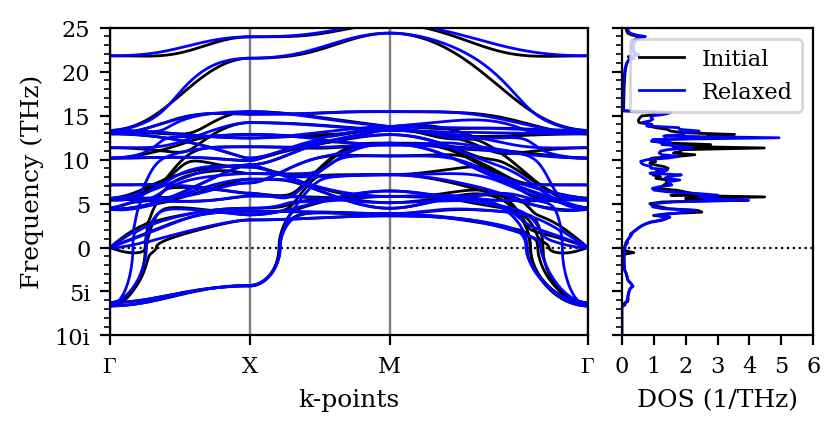

In [ ]:
phonon_initial = NEP.calculate_phonon(atoms_initial)
phonon_relaxed = NEP.calculate_phonon(atoms_initial, Nc=4)
fig = plot_dispersion([phonon_initial, phonon_relaxed], ['2x2x1', '4x4x1'], width=0.8)

      Step     Time          Energy          fmax
BFGS:    0 15:52:43     -114.132345        2.315645
BFGS:    1 15:52:43     -114.321990        1.550797
BFGS:    2 15:52:43     -114.515094        1.007144
BFGS:    3 15:52:43     -114.567973        0.699388
BFGS:    4 15:52:43     -114.645507        0.540393
BFGS:    5 15:52:43     -114.669963        0.406161
BFGS:    6 15:52:43     -114.689152        0.437384
BFGS:    7 15:52:43     -114.709387        0.371785
BFGS:    8 15:52:43     -114.722542        0.189909
BFGS:    9 15:52:43     -114.727963        0.177898
BFGS:   10 15:52:43     -114.730354        0.104835
BFGS:   11 15:52:43     -114.732148        0.062695
BFGS:   12 15:52:43     -114.732993        0.055702
BFGS:   13 15:52:43     -114.733371        0.054526
BFGS:   14 15:52:43     -114.733707        0.060319
BFGS:   15 15:52:43     -114.734275        0.088667
BFGS:   16 15:52:43     -114.735029        0.090268
BFGS:   17 15:52:43     -114.735576        0.051221
BFGS:   18 15:

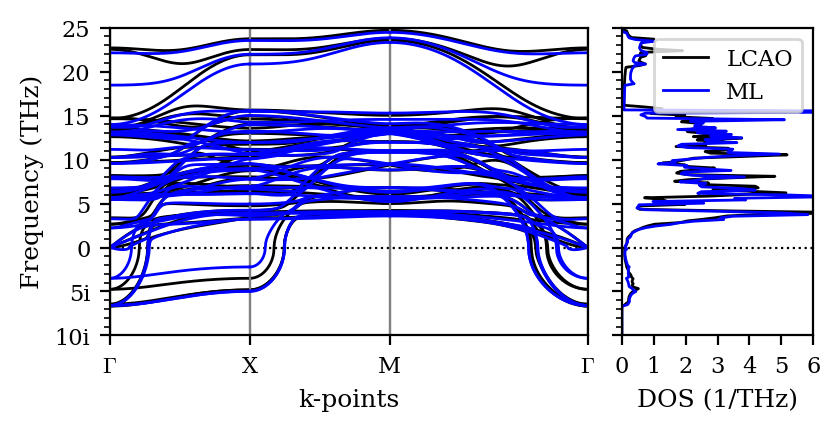

In [188]:
# Calculate phonons for the 2.5 unit cell slab structure using the trained NEP model
perovskite_slab_25 = Perovskite('BaTiO3', bulk=False, dslab=2.5).atoms
NEP.relax_atoms(perovskite_slab_25)
phonon_ML = NEP.calculate_phonon(perovskite_slab_25)
# Load the phonon DFT calculation results from the YAML file
phonon_LCAO = phonopy.load("results/slab/BaTiO3/2.5uc/0001/phonons/BaTiO3.yaml")
fig = plot_dispersion([phonon_LCAO, phonon_ML], ['LCAO', 'ML'], width=0.8)

In [189]:
strains = np.linspace(-0.025, 0.025, 21)
perovskite_slab_25 = Perovskite('BaTiO3', bulk=False, dslab=2.5)
results_slab_25 = calculate_results(perovskite_slab_25, strains)

      Step     Time          Energy          fmax
BFGS:    0 15:52:56     -114.132345        2.315645
BFGS:    1 15:52:56     -114.321990        1.550797
BFGS:    2 15:52:56     -114.515094        1.007144
BFGS:    3 15:52:56     -114.567973        0.699388
BFGS:    4 15:52:56     -114.645507        0.540393
BFGS:    5 15:52:56     -114.669963        0.406161
BFGS:    6 15:52:56     -114.689152        0.437384
BFGS:    7 15:52:56     -114.709387        0.371785
BFGS:    8 15:52:56     -114.722542        0.189909
BFGS:    9 15:52:56     -114.727963        0.177898
BFGS:   10 15:52:56     -114.730354        0.104835
BFGS:   11 15:52:56     -114.732148        0.062695
BFGS:   12 15:52:56     -114.732993        0.055702
BFGS:   13 15:52:56     -114.733371        0.054526
BFGS:   14 15:52:56     -114.733707        0.060319
BFGS:   15 15:52:56     -114.734275        0.088667
BFGS:   16 15:52:56     -114.735029        0.090268
BFGS:   17 15:52:56     -114.735576        0.051221
BFGS:   18 15:

In [192]:
frequencies, barriers, structures = unpack_results(results_slab_25, qpoints=['G', 'X'])

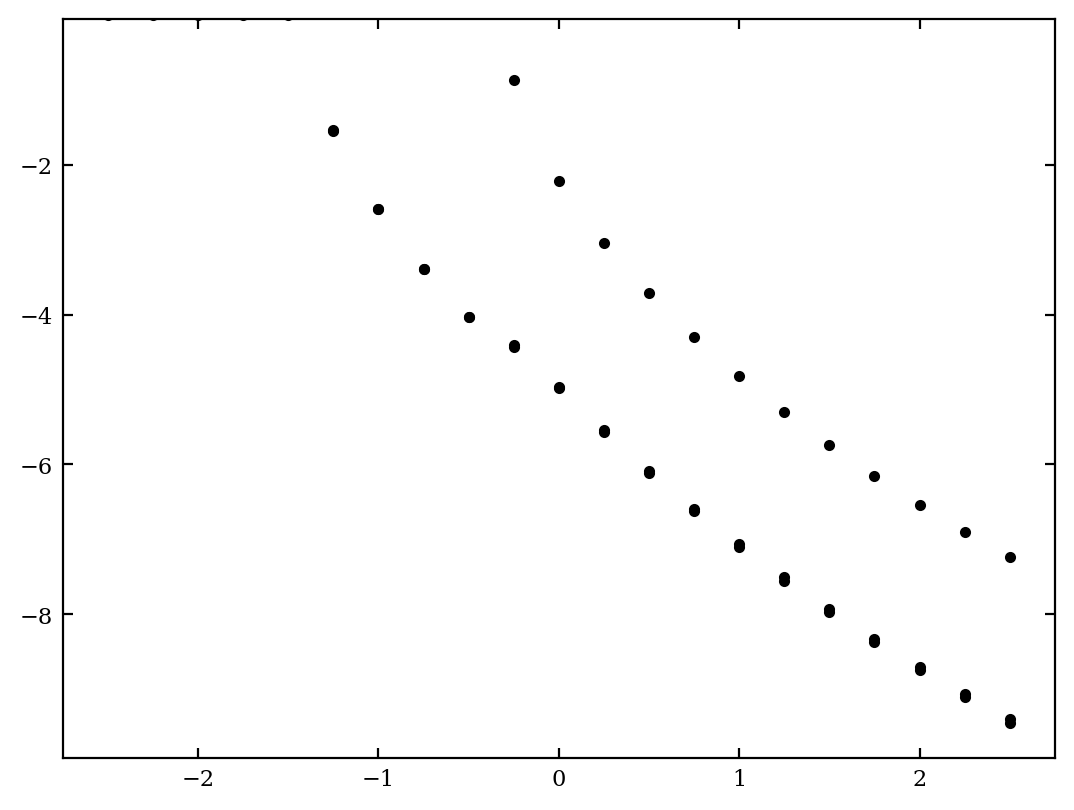

In [194]:
for i, strain in enumerate(strains):
    y = np.array(frequencies['X'][i])
    x = np.ones(len(y)) * strain * 100
    plt.plot(x, y, 'k.')

plt.ylim(None, -0.05)

plt.show()

### Molecular Dynamics

In [2]:
NEP = ActiveLearningNEP('results/ALnep')

Current iteration: 2
Loaded 838 training structures and 84 test structures
All structures have calculator results.
Existing NEP model found. Loading...
Existing active set inverse (.asi) and structures (.xyz) found. Loading...


In [79]:
# Setup MD production run with 'npt_ber' ensemble at different temperatures
NEP.setup_MD_production(ensemble='pimd_8', dt=1, n_steps=1e6, n_dump=1000,
                        temperatures=[100, 200, 300, 400, 500, 600])

      Step     Time          Energy          fmax
BFGS:    0 09:34:45      -44.270154        0.290011
BFGS:    1 09:34:45      -44.273502        0.248689
BFGS:    2 09:34:45      -44.282691        0.004178
BFGS:    3 09:34:45      -44.282694        0.000058
      Step     Time          Energy          fmax
BFGS:    0 09:34:46      -69.803858        2.195412
BFGS:    1 09:34:46      -69.983950        1.471366
BFGS:    2 09:34:46      -70.213438        0.841101
BFGS:    3 09:34:47      -70.250141        0.752768
BFGS:    4 09:34:47      -70.363773        0.092451
BFGS:    5 09:34:47      -70.364745        0.098006
BFGS:    6 09:34:47      -70.366529        0.094474
BFGS:    7 09:34:47      -70.368579        0.074477
BFGS:    8 09:34:47      -70.370868        0.050654
BFGS:    9 09:34:47      -70.371673        0.022330
BFGS:   10 09:34:47      -70.371780        0.003865
BFGS:   11 09:34:47      -70.371785        0.000122
      Step     Time          Energy          fmax
BFGS:    0 09:34:4

In [ ]:
view(read('results/ALnep/iteration_2/npt_ber_production/Ba4O20Ti8/600K/dump.xyz', index=':'))

<Popen: returncode: None args: ['/home/tbrav/projects/OxideSlabs2/.venv/bin/...>

Traceback (most recent call last):
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/tbrav/projects/OxideSlabs2/.venv/lib/python3.10/site-packages/ase/gui/pipe.py", line 34, in <module>
    main()
  File "/home/tbrav/projects/OxideSlabs2/.venv/lib/python3.10/site-packages/ase/gui/pipe.py", line 30, in main
    plt.show()
  File "/home/tbrav/projects/OxideSlabs2/.venv/lib/python3.10/site-packages/matplotlib/pyplot.py", line 613, in show
    return _get_backend_mod().show(*args, **kwargs)
  File "/home/tbrav/projects/OxideSlabs2/.venv/lib/python3.10/site-packages/matplotlib_inline/backend_inline.py", line 90, in show
    display(
  File "/home/tbrav/projects/OxideSlabs2/.venv/lib/python3.10/site-packages/IPython/core/display_functions.py", line 265, in

In [4]:
import numpy as np

def load_thermo(thermo_file, run_file):
    import re

    with open(run_file, 'r') as f:
        run_in = f.read()

    #replicate = np.array(re.findall(r'replicate\s+(\d+)\s+(\d+)\s+(\d+)', run_in)[0], dtype=int)
    time_step = np.array(re.findall(r'time_step\s+(\d+\.?\d*)', run_in), dtype=float)
    dump_thermo = np.array(re.findall(r'dump_thermo\s+(\d+)', run_in), dtype=int)
    n_steps = np.array(re.findall(r'run\s+(\d+)', run_in), dtype=int)

    N_steps = np.sum(n_steps)
    N_dumps = np.sum(n_steps // dump_thermo)

    t = np.linspace(0, N_steps*time_step, N_dumps)
    data = np.loadtxt(thermo_file)
    Ndata = data.shape[0]

    def _calculate_lattice(cell):
        # Extract lattice vectors
        a_vec = cell[:, 0]
        b_vec = cell[:, 1]
        c_vec = cell[:, 2]
        # Calculate their norms to get lattice constants
        a = np.linalg.norm(a_vec, axis=1)
        b = np.linalg.norm(b_vec, axis=1)
        c = np.linalg.norm(c_vec, axis=1)
        # Calculate angles using the dot product formula
        alpha = np.arccos(np.einsum('ij,ij->i', b_vec, c_vec) / (b * c))
        beta = np.arccos(np.einsum('ij,ij->i', a_vec, c_vec) / (a * c))
        gamma = np.arccos(np.einsum('ij,ij->i', a_vec, b_vec) / (a * b))
        # Convert angles from radians to degrees
        alpha = np.degrees(alpha)
        beta = np.degrees(beta)
        gamma = np.degrees(gamma)
        return a, b, c, alpha, beta, gamma

    cell = data[:, 9:].reshape(-1, 3, 3)
    a, b, c, alpha, beta, gamma = _calculate_lattice(cell)

    return {
        "t": t[:Ndata].flatten(),             # time in fs
        "T": data[:, 0],    # temperature in K
        "K": data[:, 1],    # kinetic energy in eV
        "U": data[:, 2],    # potential energy in eV
        "Pxx": data[:, 3],  # pressure components in GPa
        "Pyy": data[:, 4],  
        "Pzz": data[:, 5],
        "Pyz": data[:, 6],
        "Pxz": data[:, 7],
        "Pxy": data[:, 8],
        "a": a,             # lattice constants in Å
        "b": b,
        "c": c,
        "alpha": alpha,     # lattice angles in degrees
        "beta": beta,
        "gamma": gamma,
    }

In [6]:
traj = read('results/ALnep/iteration_2/npt_ber_production/Ba4O20Ti8/600K/dump.xyz', index=':')

In [11]:
supercell = read('results/ALnep/iteration_2/npt_ber_production/Ba4O20Ti8/supercell.xyz')

In [ ]:
view(traj)

<Popen: returncode: None args: ['/home/tbrav/projects/OxideSlabs2/.venv/bin/...>

Traceback (most recent call last):
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/tbrav/projects/OxideSlabs2/.venv/lib/python3.10/site-packages/ase/gui/pipe.py", line 34, in <module>
    main()
  File "/home/tbrav/projects/OxideSlabs2/.venv/lib/python3.10/site-packages/ase/gui/pipe.py", line 30, in main
    plt.show()
  File "/home/tbrav/projects/OxideSlabs2/.venv/lib/python3.10/site-packages/matplotlib/pyplot.py", line 613, in show
    return _get_backend_mod().show(*args, **kwargs)
  File "/home/tbrav/projects/OxideSlabs2/.venv/lib/python3.10/site-packages/matplotlib_inline/backend_inline.py", line 90, in show
    display(
  File "/home/tbrav/projects/OxideSlabs2/.venv/lib/python3.10/site-packages/IPython/core/display_functions.py", line 265, in

In [5]:
# read thermo.out and extract temperature and energy
thermo_file = 'results/ALnep/iteration_2/npt_ber_production/Ba8O24Ti8/600K/thermo.out'
run_file = 'results/ALnep/iteration_2/npt_ber_production/Ba8O24Ti8/600K/run.in'
thermo = load_thermo(thermo_file, run_file)

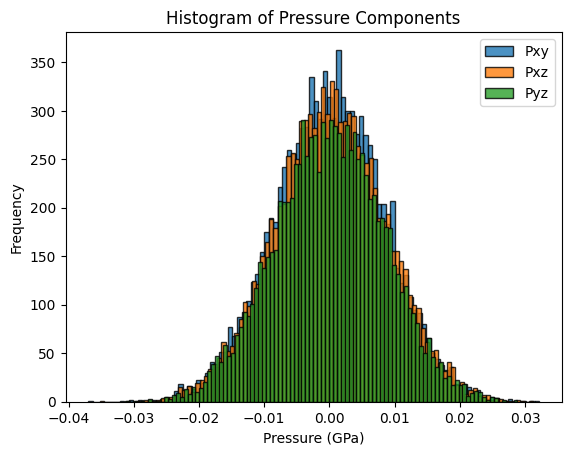

In [6]:
# Plot histogram of Pxy, Pxz, and Pyz
plt.hist(thermo["Pxy"], bins=100, alpha=0.8, edgecolor='black', label='Pxy')
plt.hist(thermo["Pxz"], bins=100, alpha=0.8, edgecolor='black', label='Pxz')
plt.hist(thermo["Pyz"], bins=100, alpha=0.8, edgecolor='black', label='Pyz')
plt.xlabel('Pressure (GPa)')
plt.ylabel('Frequency')
plt.title('Histogram of Pressure Components')
plt.legend()
plt.show()

In [73]:
# read thermo.out and extract temperature and energy
thermo_file = 'results/ALnep/iteration_2/npt_ber_production/Ba8O32Ti12/600K/thermo.out'
run_file = 'results/ALnep/iteration_2/npt_ber_production/Ba8O32Ti12/600K/run.in'
thermo = load_thermo(thermo_file, run_file)

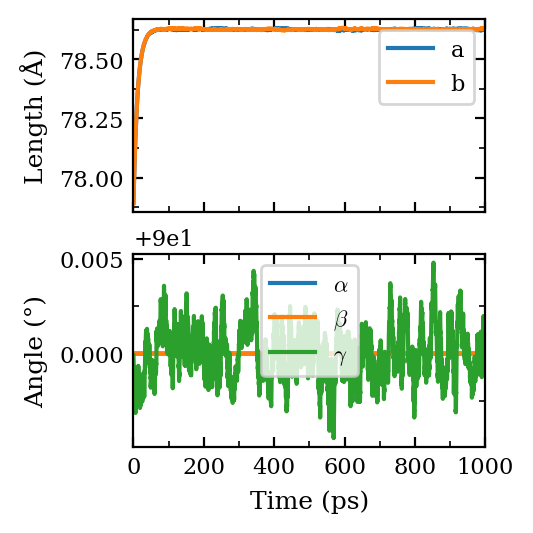

In [74]:
lf = LatexFigure()
fig, axes = lf.create(subplots=(2, 1), AR=0.5, sharex=True, width=0.5)

skip = 0

# Plot a, b, and c vs time
axes[0].plot(thermo['t'][skip:]/1e3, thermo['a'][skip:], label='a')
axes[0].plot(thermo['t'][skip:]/1e3, thermo['b'][skip:], label='b')
#axes[0].plot(thermo['t'][skip:]/1e3, thermo['c'][skip:], label='c')
"""
# Plot histogram of a, b, and c with frequency along x
axes[1].hist(thermo["a"][skip:], bins=30, alpha=0.8, density=True,
             edgecolor='black', label='a', orientation='horizontal')
axes[1].hist(thermo["b"][skip:], bins=30, alpha=0.8, density=True,
             edgecolor='black', label='b', orientation='horizontal')
axes[1].hist(thermo["c"][skip:], bins=30, alpha=0.8, density=True,
             edgecolor='black', label='c', orientation='horizontal')
"""
# Plot alpha, beta, and gamma vs time
axes[1].plot(thermo['t'][skip:]/1e3, thermo['alpha'][skip:], label='$\\alpha$')
axes[1].plot(thermo['t'][skip:]/1e3, thermo['beta'][skip:], label='$\\beta$')
axes[1].plot(thermo['t'][skip:]/1e3, thermo['gamma'][skip:], label='$\\gamma$')


axes[0].set_xlim(thermo['t'][skip:][0]/1e3, thermo['t'][skip:][-1]/1e3)
axes[0].set_ylabel('Length (Å)')
axes[0].legend()

axes[1].set_xlabel('Time (ps)')
axes[1].set_xlim(thermo['t'][skip:][0]/1e3, thermo['t'][skip:][-1]/1e3)
axes[1].set_ylabel('Angle (°)')
axes[1].legend()

#axes[1].set_ylabel('Frequency')
plt.show()

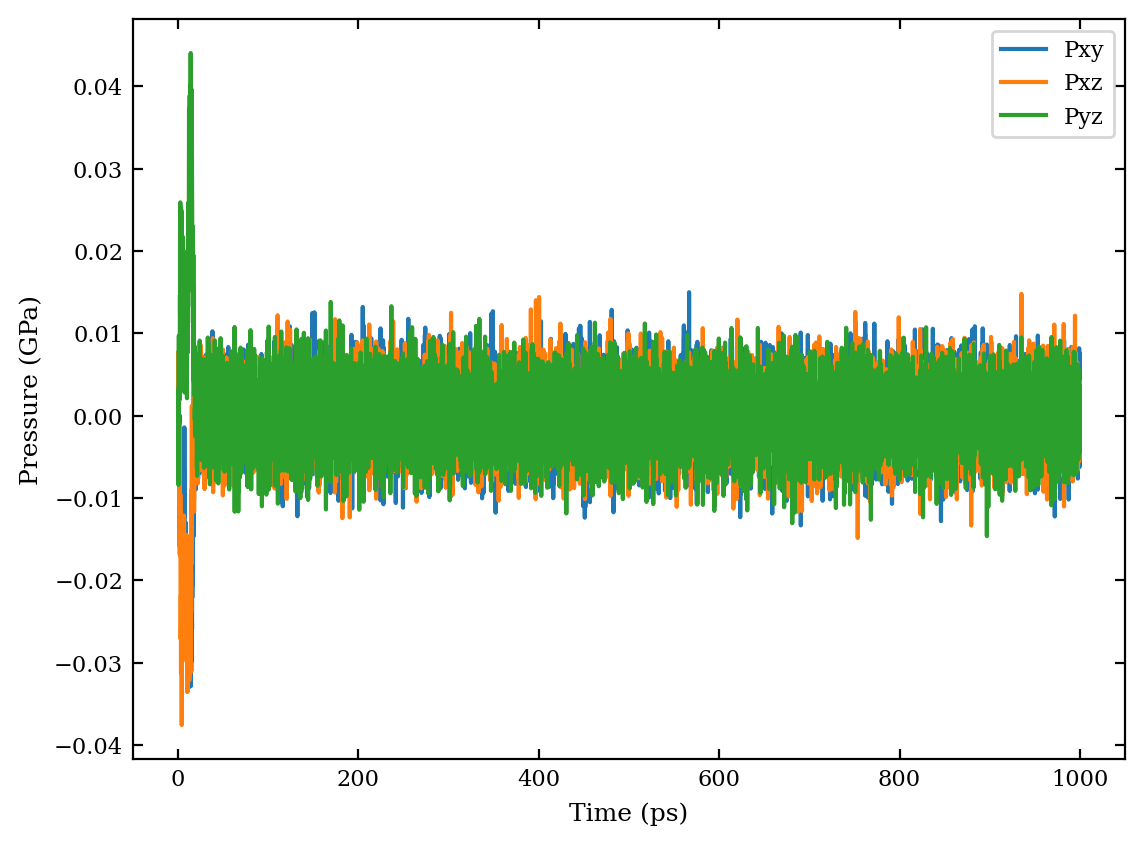

In [72]:
plt.plot(thermo['t']/1e3, thermo['Pxy'], label='Pxy')
plt.plot(thermo['t']/1e3, thermo['Pxz'], label='Pxz')
plt.plot(thermo['t']/1e3, thermo['Pyz'], label='Pyz')
#plt.plot(thermo['t']/1e3, thermo['cell'][2], label='c')
plt.xlabel('Time (ps)')
#plt.ylabel('Lattice Constant (Å/u.c.)')
plt.ylabel('Pressure (GPa)')
plt.legend()
plt.show()

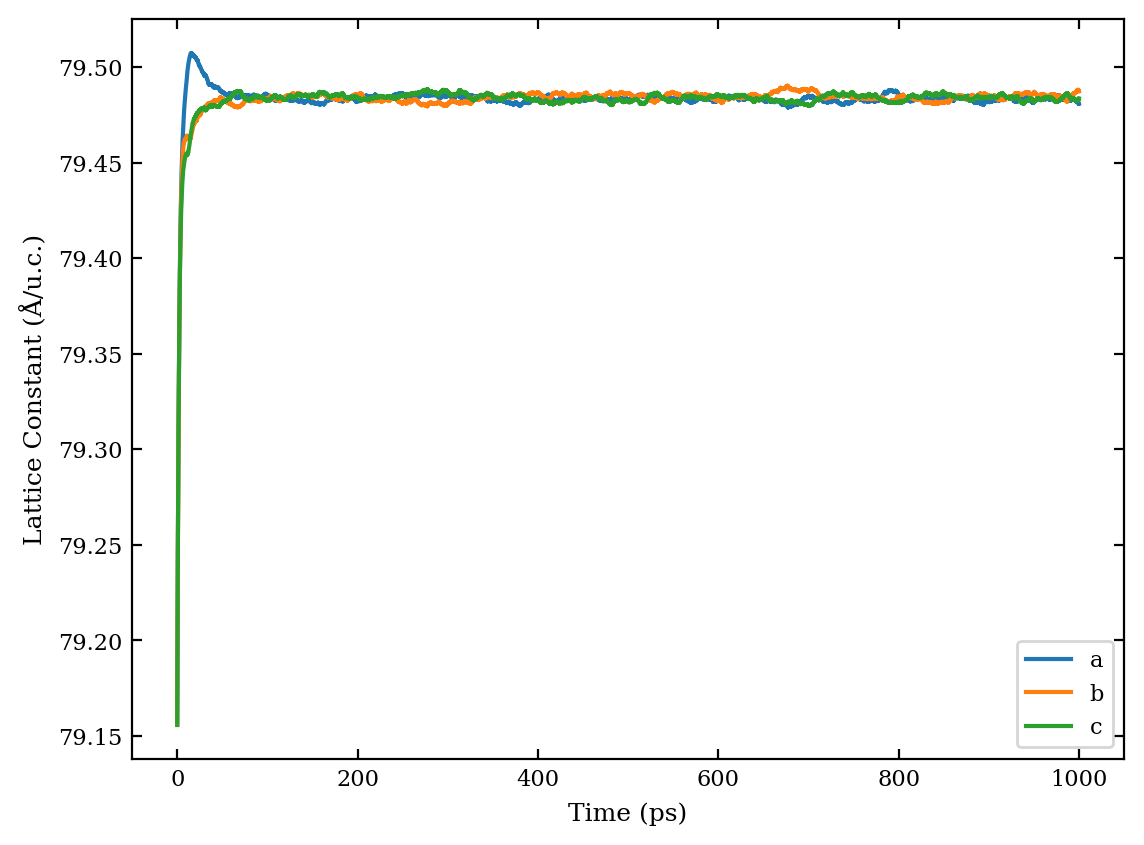

In [18]:
plt.plot(thermo['t']/1e3, thermo['a'], label='a')
plt.plot(thermo['t']/1e3, thermo['b'], label='b')
plt.plot(thermo['t']/1e3, thermo['c'], label='c')
plt.xlabel('Time (ps)')
plt.ylabel('Lattice Constant (Å/u.c.)')
plt.legend()
plt.show()

In [93]:
a = np.array([])
b = np.array([])
c = np.array([])
T = np.array([])

for temp in [100, 200, 300, 400, 500, 600]:
    thermo_file = f'results/ALnep/iteration_2/npt_ber_production/Ba8O24Ti8/{temp}K/thermo.out'
    run_file = f'results/ALnep/iteration_2/npt_ber_production/Ba8O24Ti8/{temp}K/run.in'
    thermo = load_thermo(thermo_file, run_file)

    indx = np.where(thermo['t'] > 800*1e3)[0][0]

    T = np.append(T, thermo['T'][indx:])
    a = np.append(a, thermo['a'][indx:])
    b = np.append(b, thermo['b'][indx:])
    c = np.append(c, thermo['c'][indx:])

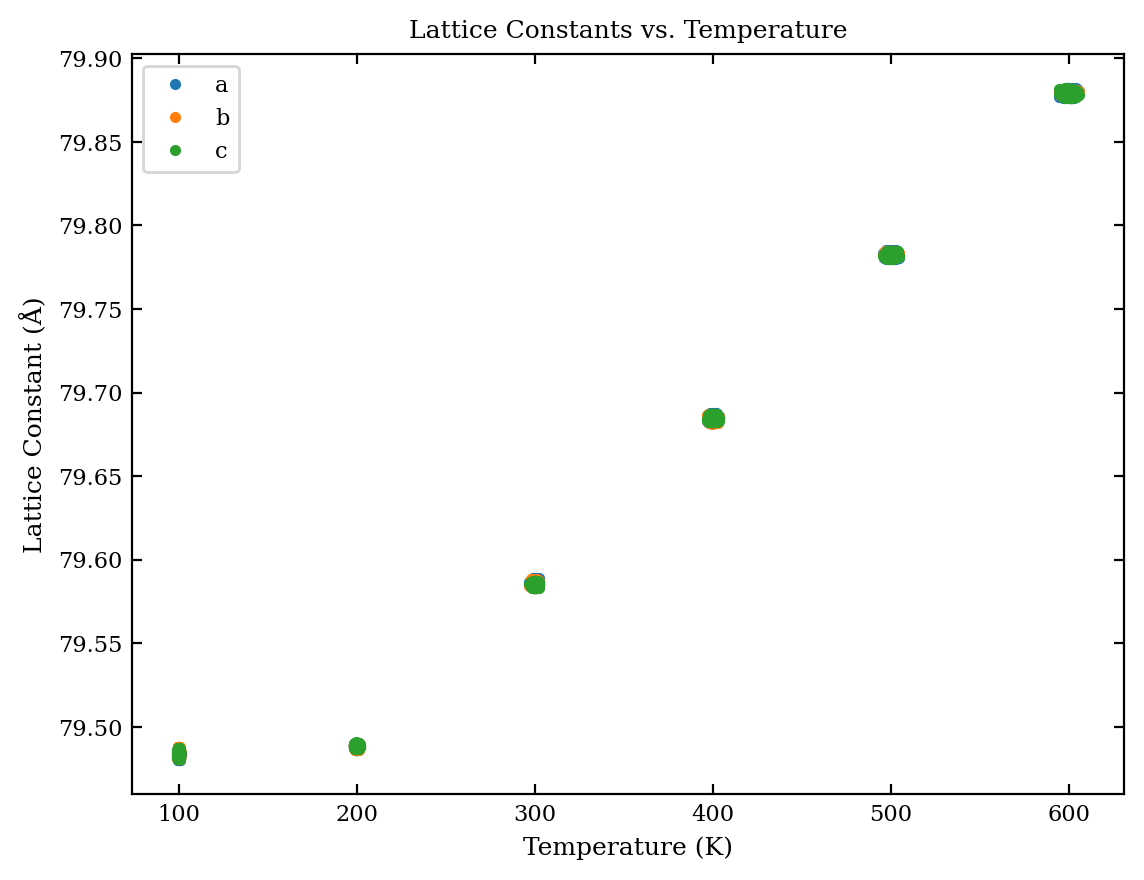

In [94]:
plt.plot(T, a, '.', label='a')
plt.plot(T, b, '.', label='b')
plt.plot(T, c, '.', label='c')
plt.xlabel('Temperature (K)')
plt.ylabel('Lattice Constant (Å)')
plt.title('Lattice Constants vs. Temperature')
plt.legend()
plt.show()

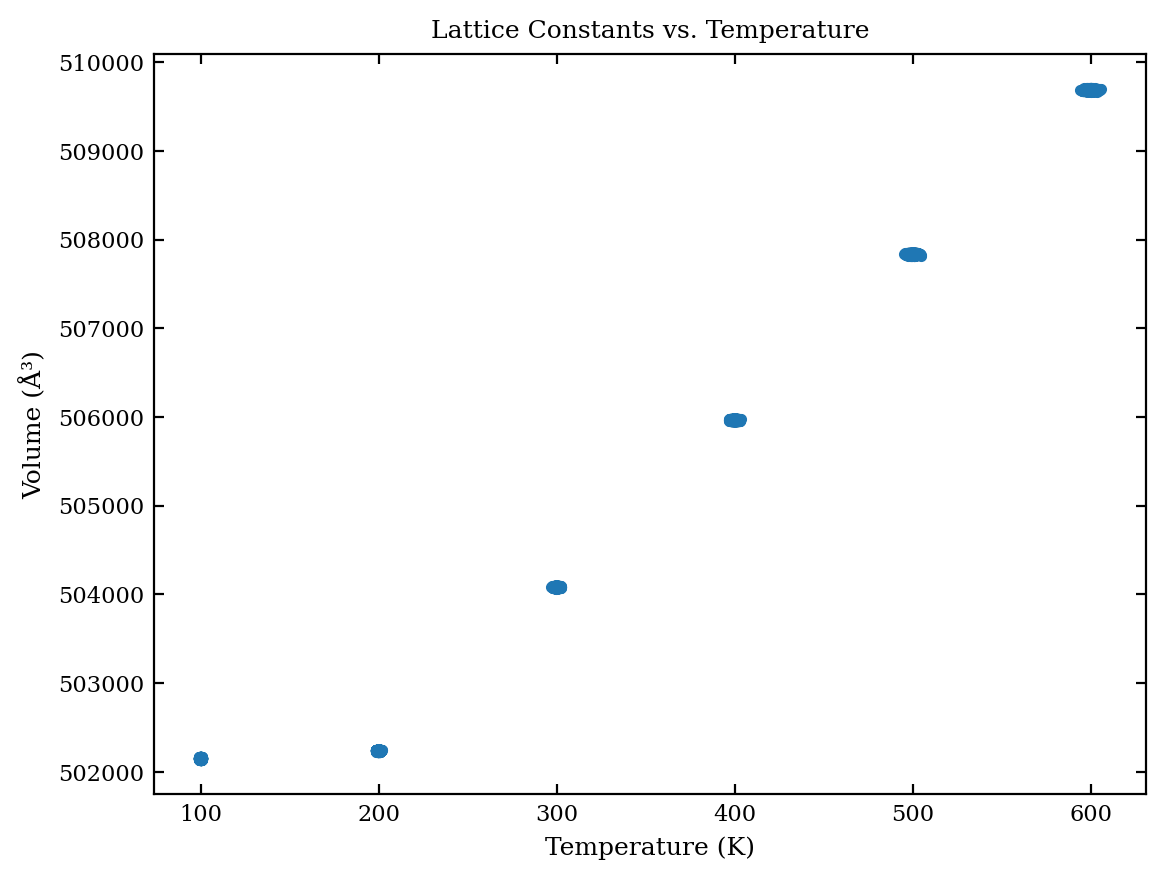

In [95]:
plt.plot(T, a*b*c, '.')
plt.xlabel('Temperature (K)')
plt.ylabel('Volume (Å³)')
plt.title('Lattice Constants vs. Temperature')
#plt.legend()
plt.show()

In [96]:
a = np.array([])
b = np.array([])
c = np.array([])
T = np.array([])

for temp in [100, 200, 300, 400, 500, 600]:
    thermo_file = f'results/ALnep/iteration_2/pimd_8_production/Ba8O24Ti8/{temp}K/thermo.out'
    run_file = f'results/ALnep/iteration_2/pimd_8_production/Ba8O24Ti8/{temp}K/run.in'
    thermo = load_thermo(thermo_file, run_file)

    indx = np.where(thermo['t'] > 800*1e3)[0][0]

    T = np.append(T, thermo['T'][indx:])
    a = np.append(a, thermo['a'][indx:])
    b = np.append(b, thermo['b'][indx:])
    c = np.append(c, thermo['c'][indx:])

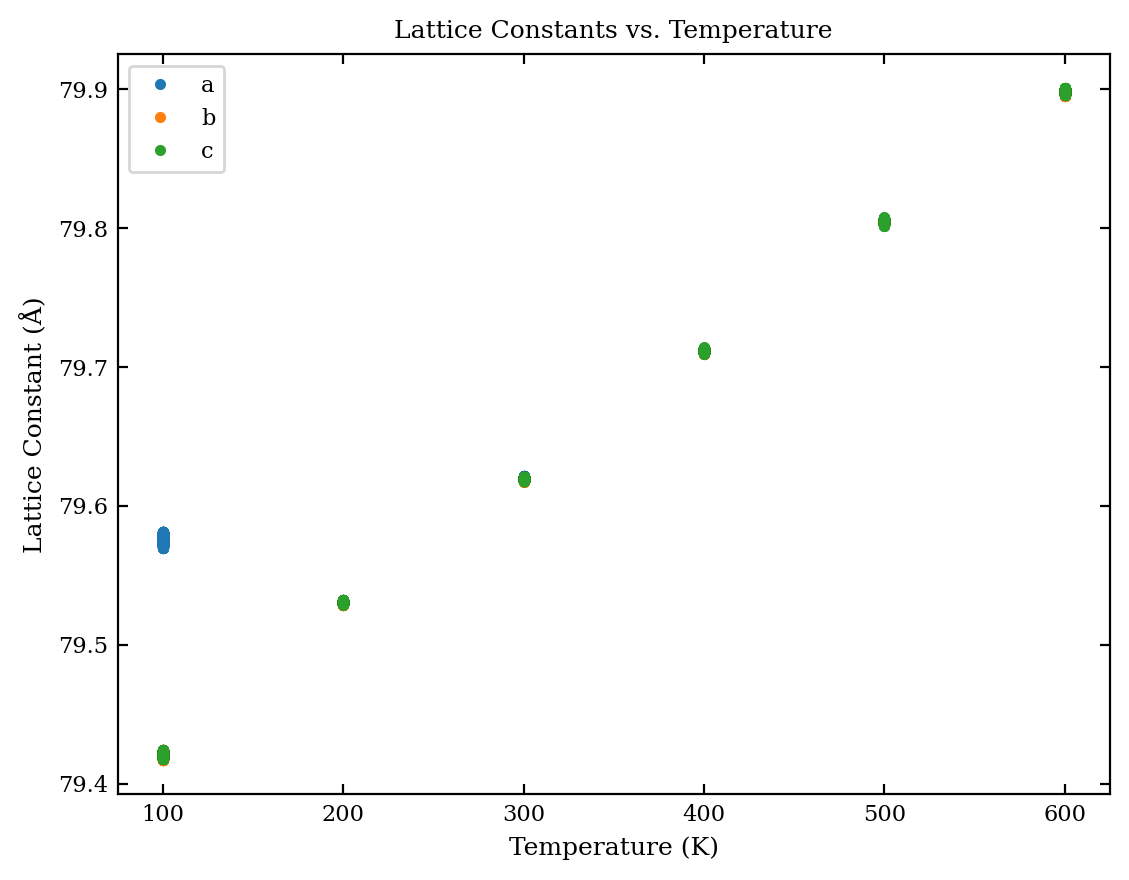

In [97]:
plt.plot(T, a, '.', label='a')
plt.plot(T, b, '.', label='b')
plt.plot(T, c, '.', label='c')
plt.xlabel('Temperature (K)')
plt.ylabel('Lattice Constant (Å)')
plt.title('Lattice Constants vs. Temperature')
plt.legend()
plt.show()

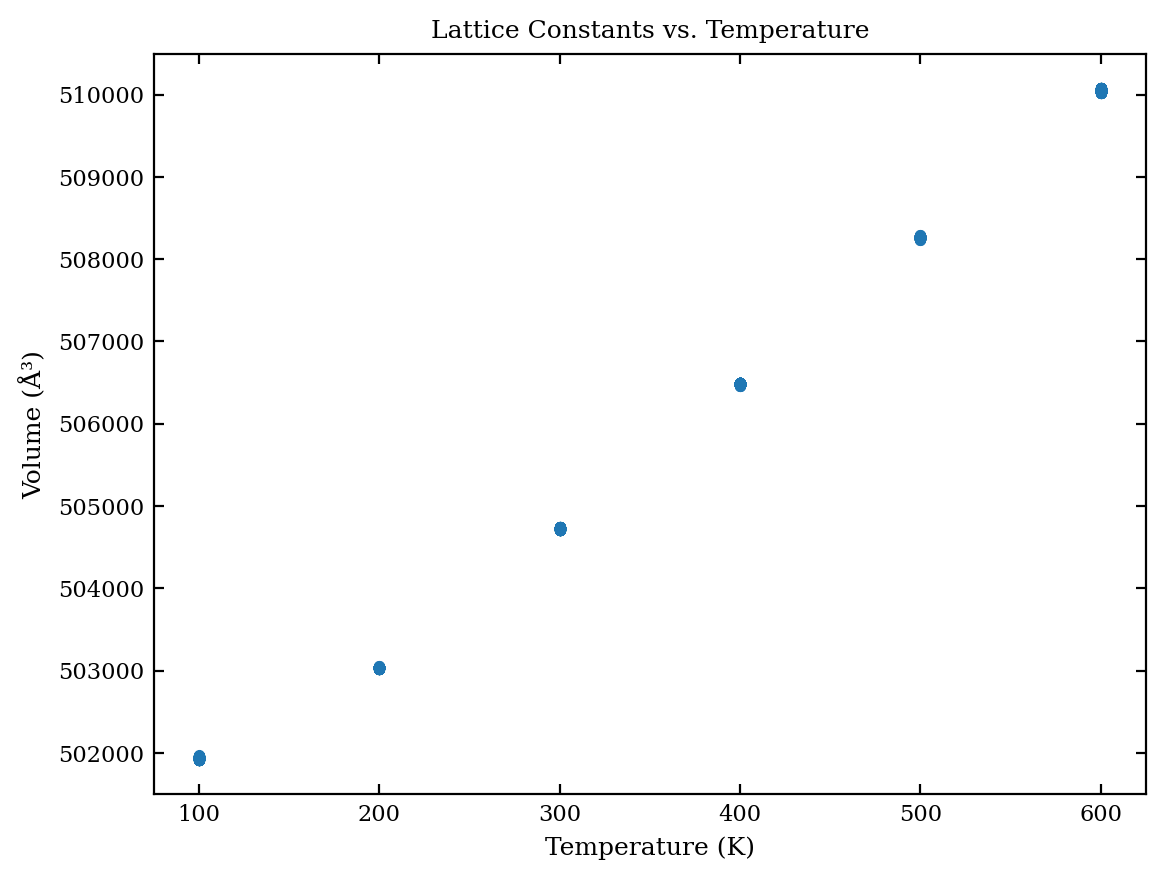

In [98]:
plt.plot(T, a*b*c, '.')
plt.xlabel('Temperature (K)')
plt.ylabel('Volume (Å³)')
plt.title('Lattice Constants vs. Temperature')
#plt.legend()
plt.show()

### Spectral Energy Density (SED)

In [2]:
NEP = ActiveLearningNEP('results/ALnep')

Current iteration: 2
Loaded 838 training structures and 84 test structures
All structures have calculator results.
Existing NEP model found. Loading...
Existing active set inverse (.asi) and structures (.xyz) found. Loading...


In [3]:
from src.gpumdIO import create_run_in
print(create_run_in(ensemble='nve', dt=1, n_steps=1e4, n_dump=1e4, T0=500, T1=500))

Maximum frequency that can be resolved is 500.0 THz.
potential ../../../nep.txt
velocity 500
time_step 1

dump_thermo 1
ensemble nvt_lan 500 500 100
run 1000

dump_netcdf 1 1
ensemble nve
run 10000



In [5]:
# Setup MD production run with 'nve' ensemble at different temperatures
NEP.setup_MD_production(ensemble='nve', dt=1, n_steps=1e4, n_dump=1e4,
                        temperatures=[500], N_rep=10)

      Step     Time          Energy          fmax
BFGS:    0 11:54:21     -114.132345        2.315645
BFGS:    1 11:54:21     -114.321990        1.550797
BFGS:    2 11:54:21     -114.515094        1.007144
BFGS:    3 11:54:21     -114.567973        0.699388
BFGS:    4 11:54:21     -114.645507        0.540393
BFGS:    5 11:54:21     -114.669963        0.406161
BFGS:    6 11:54:21     -114.689152        0.437384
BFGS:    7 11:54:21     -114.709387        0.371785
BFGS:    8 11:54:21     -114.722542        0.189909
BFGS:    9 11:54:21     -114.727963        0.177898
BFGS:   10 11:54:21     -114.730354        0.104835
BFGS:   11 11:54:21     -114.732148        0.062695
BFGS:   12 11:54:21     -114.732993        0.055702
BFGS:   13 11:54:21     -114.733371        0.054526
BFGS:   14 11:54:21     -114.733707        0.060319
BFGS:   15 11:54:21     -114.734275        0.088667
BFGS:   16 11:54:21     -114.735029        0.090268
BFGS:   17 11:54:21     -114.735576        0.051221
BFGS:   18 11:

In [2]:
unitcell = read('results/ALnep/iteration_2/nve_production_old4/Ba8O24Ti8/model.xyz')

In [19]:
view(unitcell)

<Popen: returncode: None args: ['/home/tbrav/projects/OxideSlabs2/.venv/bin/...>

In [3]:
from src.structure import Perovskite
from src.phononcalc import get_phonon_dispersion, plot_dispersion

In [4]:
NEP = ActiveLearningNEP('results/ALnep')
phonon_ML = NEP.calculate_phonon(unitcell)

Current iteration: 2


Loaded 838 training structures and 84 test structures
All structures have calculator results.
Existing NEP model found. Loading...
Existing active set inverse (.asi) and structures (.xyz) found. Loading...


In [5]:
# Extract phonon dispersion data
distances, freqencies, _, path_labels = get_phonon_dispersion(phonon_ML, custom=True)
xticks = np.array([dist[0] for dist in distances] + [distances[-1][-1]])

IndexError: list index out of range

In [6]:
distances

[]

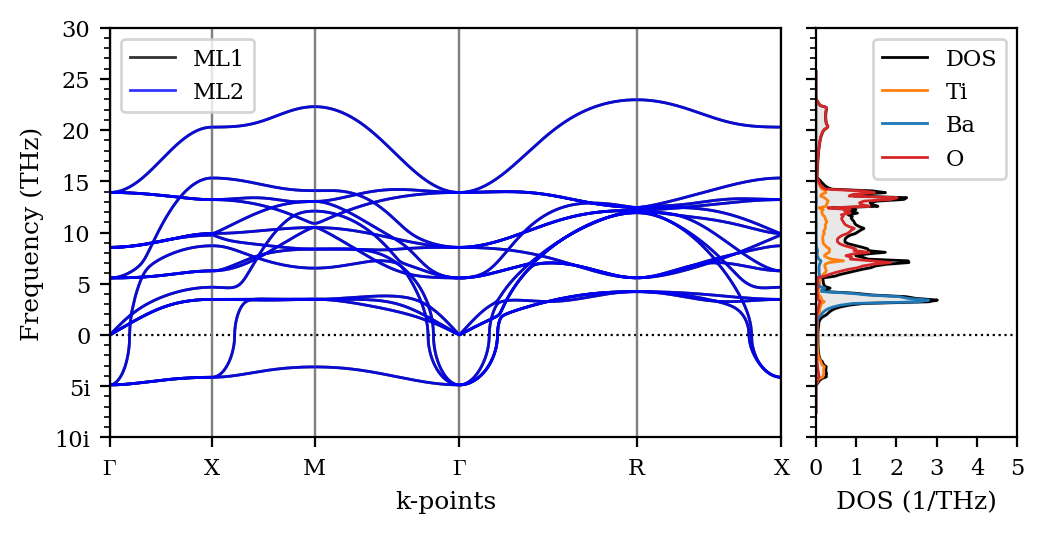

In [5]:
fig = plot_dispersion([phonon_ML, phonon_ML], ['ML1', 'ML2'], width=1, pDOS=True)

In [153]:
from ase.build import bulk

# Create your atoms object (e.g., Silicon)
atoms = bulk('Si', 'diamond', cubic=True)

# Generate the symmetry path
bandpath = atoms.cell.bandpath()

# Extract the high-symmetry points and k-points
k_points = bandpath.kpts
special_points = bandpath.special_points

print("Special points:", special_points)
print("Path:", bandpath.path)

Special points: {'G': array([0., 0., 0.]), 'M': array([0.5, 0.5, 0. ]), 'R': array([0.5, 0.5, 0.5]), 'X': array([0. , 0.5, 0. ])}
Path: GXMGRX,MR


In [154]:
# Seperate text by ',' and take the first part
path = bandpath.path.split(',')[0]

In [ ]:
# Create list of arrays of k-points for each segment
path_points = []
path_labels = []
for i in range(len(path)):
    path_points.append(bandpath.special_points[path[i]].tolist())
    path_labels.append(path[i])

In [165]:
# Convert from array to list
bandpath.special_points[path[i]].tolist()

[0.0, 0.5, 0.0]

In [163]:
[[[0.0, 0.0, 0.0],[0.5, 0.0, 0.0],[0.5, 0.5, 0.5],
                [0.5, 0.5, 0.0],[0.0, 0.0, 0.0]]]

[[[0.0, 0.0, 0.0],
  [0.5, 0.0, 0.0],
  [0.5, 0.5, 0.5],
  [0.5, 0.5, 0.0],
  [0.0, 0.0, 0.0]]]

In [168]:
path_labels

['G', 'X', 'M', 'G', 'R', 'X']

In [142]:
path

BandPath(path='GXMGRX,MR', cell=[3x3], special_points={GMRX}, kpts=[22x3])

In [30]:
test = read('results/ALnep/iteration_2/nve_production/Ba4O20Ti8/500K/model.xyz', index=0)

In [32]:
test.pbc = True

In [33]:
test

Atoms(symbols='Ba400O2000Ti800', pbc=True, cell=[77.02687425625041, 77.02687425625041, 43.98])

In [18]:
supercell

Atoms(symbols='Ba1000O3000Ti1000', pbc=True, cell=[39.572479440972074, 39.572479440972074, 39.572479440972074])

In [31]:
# Make dictionary of species and values are lists of indices where they occur
species_dict = {}
for i, symbol in enumerate(supercell.get_chemical_symbols()):
    if symbol not in species_dict:
        species_dict[symbol] = []
    species_dict[symbol].append(i)

In [48]:
path = 'results/ALnep/iteration_2/nve_production/Ba8O24Ti8/500K'
import re
from dynasor import Trajectory, compute_spectral_energy_density
from dynasor.qpoints.lattice import Lattice
from dynasor.units import radians_per_fs_to_THz
from src.phononcalc import get_phonon_dispersion

run_file = os.path.join(path, 'run.in')
        
with open(run_file, 'r') as f:
    run_in = f.read()

dt = np.sum(np.array(re.findall(r'time_step\s+(\d+\.?\d*)', run_in), dtype=float))
ddump = np.sum(np.array(re.findall(r'dump_netcdf\s+(\d+)', run_in), dtype=int))


unitcell = read(os.path.join(os.path.dirname(path), 'unitcell.xyz'))
supercell = read(os.path.join(os.path.dirname(path), 'supercell.xyz'))

# Make dictionary of species and values are lists of indices where they occur
species_dict = {}
for i, symbol in enumerate(supercell.get_chemical_symbols()):
    if symbol not in species_dict:
        species_dict[symbol] = []
    species_dict[symbol].append(i)

phonon = NEP.calculate_phonon(unitcell)
phonopy_dists, phonopy_freqs, phonopy_paths, pathlabels = get_phonon_dispersion(phonon)

lat = Lattice(unitcell.cell, supercell.cell)

dyna_paths, dyna_dists = [], []
for p, d in zip(phonopy_paths, phonopy_dists):
    p0, p1 = p[[0, -1]]

    dyna_path, dyna_dist = lat.make_path(p0, p1)
    dyna_paths.append(dyna_path)

    d0, d1 = d[[0, -1]]
    dyna_dists.append(d0 + (d1 - d0) * dyna_dist)

#phonopy_path = lat.reduced_to_cartesian(np.vstack(phonopy_paths))
dynasor_path = np.vstack(dyna_paths)

traj = Trajectory(os.path.join(path, 'movie.nc'),
                    trajectory_format='nc', atomic_indices=species_dict,
                    length_unit='Angstrom', time_unit='fs', frame_start=9000)

w, sed = compute_spectral_energy_density(traj,
        ideal_supercell=supercell,
        primitive_cell=unitcell,
        q_points=dynasor_path,
        dt=dt*ddump,
        partial=True)

dyna_freqs = w * radians_per_fs_to_THz

INFO 2026-06-01 13:21:15: Trajectory file: results/ALnep/iteration_2/nve_production/Ba8O24Ti8/500K/movie.nc
INFO 2026-06-01 13:21:15: Total number of particles: 5000
INFO 2026-06-01 13:21:15: Number of atom types: 3
INFO 2026-06-01 13:21:15: Number of atoms of type Ba: 1000
INFO 2026-06-01 13:21:15: Number of atoms of type O: 3000
INFO 2026-06-01 13:21:15: Number of atoms of type Ti: 1000
INFO 2026-06-01 13:21:15: Simulation cell (in Angstrom):
[[39.57248  0.       0.     ]
 [ 0.      39.57248  0.     ]
 [ 0.       0.      39.57248]]
INFO 2026-06-01 13:21:15: Running SED
INFO 2026-06-01 13:21:15: Time between consecutive frames (dt * frame_step): 1.0 fs
INFO 2026-06-01 13:21:15: Number of atoms in primitive_cell: 5
INFO 2026-06-01 13:21:15: Number of atoms in ideal_supercell: 5000
INFO 2026-06-01 13:21:15: Number of q-points: 30


/home/tbrav/projects/OxideSlabs2/.venv/lib/python3.10/site-packages/MDAnalysis/core/universe.py:1672: UserWarning: there is no reference attributes in this universe to guess types from
  warnings.warn(str(e))
/home/tbrav/projects/OxideSlabs2/.venv/lib/python3.10/site-packages/MDAnalysis/core/universe.py:1672: UserWarning: there is no reference attributes (elements, types, or names) in this universe to guess mass from
  warnings.warn(str(e))


INFO 2026-06-01 13:28:04: Number of snapshots: 1000


In [ ]:
'results/ALnep/iteration_2/nve_production/Ba8O24Ti8/500K/movie.nc'

In [50]:
NEP.calculate_sed(path='nve_production/Ba8O24Ti8/500K')

INFO 2026-05-29 11:40:25: Trajectory file: results/ALnep/iteration_2/nve_production/Ba8O24Ti8/500K/dump.xyz
INFO 2026-05-29 11:40:25: Total number of particles: 5000
INFO 2026-05-29 11:40:25: Number of atom types: 3
INFO 2026-05-29 11:40:25: Number of atoms of type Ba: 1000
INFO 2026-05-29 11:40:25: Number of atoms of type O: 3000
INFO 2026-05-29 11:40:25: Number of atoms of type Ti: 1000
INFO 2026-05-29 11:40:25: Simulation cell (in Angstrom):
[[39.57247944  0.          0.        ]
 [ 0.         39.57247944  0.        ]
 [ 0.          0.         39.57247944]]
Numba threads: 12
Thread layer: omp
INFO 2026-05-29 11:40:25: Running SED
INFO 2026-05-29 11:40:25: Time between consecutive frames (dt * frame_step): 10.0 fs
INFO 2026-05-29 11:40:25: Number of atoms in primitive_cell: 5
INFO 2026-05-29 11:40:25: Number of atoms in ideal_supercell: 5000
INFO 2026-05-29 11:40:25: Number of q-points: 30
INFO 2026-05-29 11:40:45: Number of snapshots: 1000


In [113]:
traject = read('results/ALnep/iteration_2/nve_production/Ba8O24Ti8/500K/dump.xyz', index=':')

In [114]:
traject[0]

Atoms(symbols='Ba1000O3000Ti1000', pbc=True, cell=[39.57247944, 39.57247944, 39.57247944], vel=..., calculator=SinglePointCalculator(...))

In [ ]:
view(read('results/ALnep/iteration_2/nve_production/Ba8O24Ti8/500K/dump.xyz', index=':'))

<Popen: returncode: None args: ['/home/tbrav/projects/OxideSlabs2/.venv/bin/...>

Traceback (most recent call last):
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/tbrav/miniconda3/envs/siesta-env/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/tbrav/projects/OxideSlabs2/.venv/lib/python3.10/site-packages/ase/gui/pipe.py", line 34, in <module>
    main()
  File "/home/tbrav/projects/OxideSlabs2/.venv/lib/python3.10/site-packages/ase/gui/pipe.py", line 30, in main
    plt.show()
  File "/home/tbrav/projects/OxideSlabs2/.venv/lib/python3.10/site-packages/matplotlib/pyplot.py", line 613, in show
    return _get_backend_mod().show(*args, **kwargs)
  File "/home/tbrav/projects/OxideSlabs2/.venv/lib/python3.10/site-packages/matplotlib_inline/backend_inline.py", line 90, in show
    display(
  File "/home/tbrav/projects/OxideSlabs2/.venv/lib/python3.10/site-packages/IPython/core/display_functions.py", line 265, in

In [101]:
from src.phononcalc import get_phonon_dispersion
unitcell = read('results/ALnep/iteration_2/nve_production/Ba8O24Ti8/unitcell.xyz')
phonon = NEP.calculate_phonon(unitcell)
phonopy_dists, phonopy_freqs, phonopy_paths, pathlabels = get_phonon_dispersion(phonon)

In [55]:
data = np.load('results/ALnep/iteration_2/nve_production_test/Ba8O24Ti8/500K/sed.npz')
dyna_dists = data['dists']
dyna_freqs = data['freqs']
sed = data['sed']
sed_total = np.sum(sed, axis=(2, 3))
sed_partial = {}
for symbol in set(unitcell.symbols):
    indices = [i for i, s in enumerate(unitcell.symbols) if s == symbol]
    sed_partial[symbol] = np.sum(np.sum(sed, axis=3)[:, :, indices], axis=2)

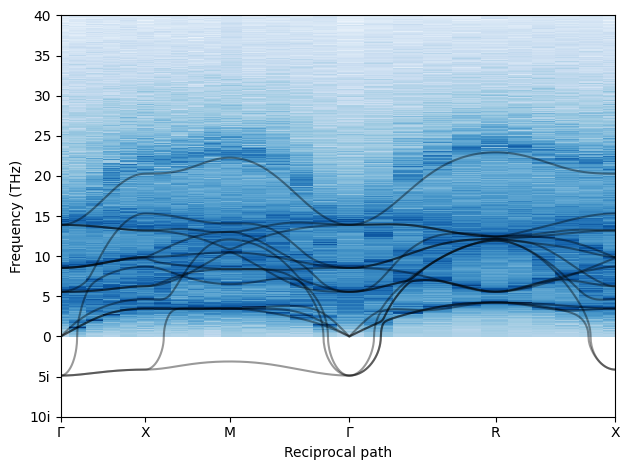

In [56]:
# Plot
#fig, ax = plt.subplots(figsize=(3.4, 2.8), dpi=140)
fig, ax = plt.subplots()

# Define tickmarks for the x- and y-axis
y_tickmarks = np.arange(-10, 41, 5)
# Convert tickmarks to strings with i for negative numbers
y_ticklabels = []
for tick in y_tickmarks:
    if tick < 0:
        y_ticklabels.append(f'{abs(tick)}i')
    else:
        y_ticklabels.append(f'{tick}')

# dynasor
#ax.pcolormesh(np.hstack(dyna_dists), freqs, np.log(sed).T,
#              shading='auto', rasterized=True, cmap='Blues')
ax.pcolormesh(np.hstack(dyna_dists), dyna_freqs, np.log(sed_total).T,
              cmap='Blues', shading='auto', rasterized=True)

# phonopy
ax.plot(np.hstack(phonopy_dists), np.vstack(phonopy_freqs), color='black', alpha=0.4)

# indicate q-points that were sampled
#ax.vlines(np.hstack(dyna_dists), np.min(dyna_freqs), np.max(dyna_freqs), color='gray', alpha=0.5)

xticks = np.array([dist[0] for dist in phonopy_dists] + [phonopy_dists[-1][-1]])

ax.set_xlabel('Reciprocal path')
ax.set_ylabel('Frequency (THz)')
ax.set_xticks(xticks, pathlabels)

ax.set_xlim(xticks[0], xticks[-1])
ax.set_ylim(y_tickmarks[0], y_tickmarks[-1])
ax.set_yticks(y_tickmarks, y_ticklabels)

fig.tight_layout()

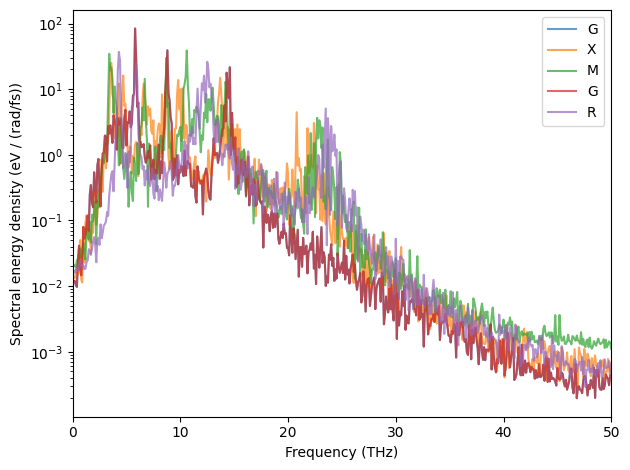

In [57]:
special_indices = np.cumsum([0] + [len(d) for d in dyna_dists])[:-1]

fig, ax = plt.subplots()

for label, spectrum in zip('GXMGR', sed_total[special_indices]):
    ax.semilogy(dyna_freqs, spectrum, label=label, alpha=0.7)
ax.set_xlim(0, 50)
ax.set_xlabel('Frequency (THz)')
ax.set_ylabel('Spectral energy density (eV / (rad/fs))')
ax.legend()

fig.tight_layout()

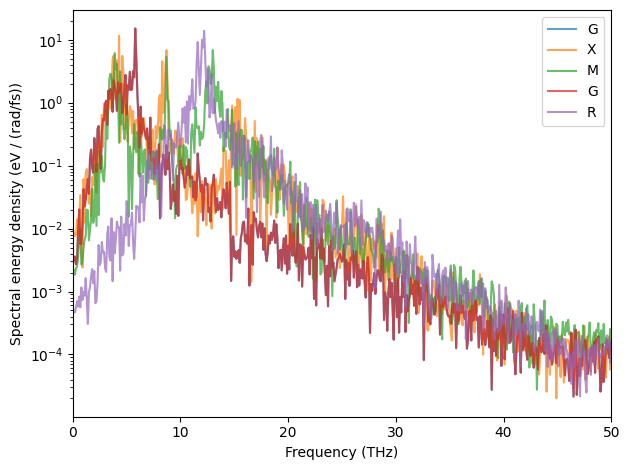

In [58]:
special_indices = np.cumsum([0] + [len(d) for d in dyna_dists])[:-1]

fig, ax = plt.subplots()

for label, spectrum in zip('GXMGR', sed_partial['Ti'][special_indices]):
    ax.semilogy(dyna_freqs, spectrum, label=label, alpha=0.7)
ax.set_xlim(0, 50)
ax.set_xlabel('Frequency (THz)')
ax.set_ylabel('Spectral energy density (eV / (rad/fs))')
ax.legend()

fig.tight_layout()

In [59]:
# SED normalization test
from ase.units import kB
from dynasor.units import radians_per_fs_to_THz

n_bands = len(unitcell) * 3
print('Number of bands', n_bands)
for label, spectrum in zip('GXMR', sed_total[special_indices]):
    I = np.trapezoid(spectrum, dyna_freqs / radians_per_fs_to_THz)
    T = I / (1 / 2 * kB * n_bands)
    print(f'q-point {label}: SED temperature {T:.2f} K')

Number of bands 15
q-point G: SED temperature 444.22 K
q-point X: SED temperature 472.79 K
q-point M: SED temperature 570.28 K
q-point R: SED temperature 444.22 K


# Tests

In [13]:
from src.structure import Perovskite
perovskite = Perovskite('BaTiO3')
atoms = perovskite.atoms
calculator = CPUNEP('results/MLtest/nepmodel_split1/nep.txt')
atoms.calc = calculator
relax_structure(atoms, fmax=0.00001)

In [14]:
atoms.cell

Cell([[3.961134456663261, -1.739646449265033e-18, 2.3777005252795005e-18], [3.2816032633461203e-17, 3.9611344566632525, -4.53674797921587e-15], [4.013580058709373e-17, -4.467379310396215e-15, 3.9611344566632507]])

In [58]:
phonon_ML = get_force_constants(atoms, calculator, [2, 2, 2])

In [154]:
from src.phononcalc import get_phonon_dispersion, get_phonon_dos, get_phonon_pdos, order_labels
from src.frozenphonon import get_displacement, get_unstable_mode_groups
from src.phononASE import phonon_to_atoms
from src.plotsettings import PlotSettings
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from ase.io import read, write
from ase.visualize import view
import numpy as np
import pandas as pd

In [60]:
# Load the phonon calculation results from the YAML file
phonon_LCAO = phonopy.load("results/bulk/BaTiO3/0082/phonons/BaTiO3.yaml")

In [164]:
def displace_imaginary_modes(phonon, n_points=101, deg=True):
    """
    """
    # Get current working directory (cwd)
    #cwd = os.getcwd()
    # Unitcell and formula from phonon object
    unitcell = phonon_to_atoms(phonon, cell='unit')
    #formula = unitcell.symbols

    # Dictionary for q-points
    q_dict = {
        'G': [0.0, 0.0, 0.0],
        'X': [0.5, 0.0, 0.0],
        'R': [0.5, 0.5, 0.5],
        'M': [0.5, 0.5, 0.0],
    }

    dd_dict = {
        'G': 1/n_points,
        'X': 1.5/n_points,
        'R': 5/n_points,
        'M': 3/n_points,
    }

    results = {}

    for qpoint in q_dict.keys():

        q = q_dict[qpoint]
        dd = dd_dict[qpoint]

        groups, stable = get_unstable_mode_groups(phonon, q)

        if stable:
            print(f"No unstable modes found at {qpoint}")
            continue

        results[qpoint] = {}

        for g_id, group in enumerate(groups):

            modes = group["modes"]
            freq = group["frequency"]

            if not deg:
                modes = [modes[0]]

            results[qpoint][g_id] = {}

            for mode_id, modevec in enumerate(modes):

                modevec_sc, supercell, supercell_matrix = get_displacement(unitcell, q, modevec)

                nx, ny, nz = supercell_matrix.diagonal().astype(int)
                ncells = nx * ny * nz

                calc = CPUNEP(os.path.join(NEP.iter_dir, 'nep.txt'))

                supercell_disp = supercell.copy()
                ref_positions = supercell.positions.copy()
                supercell_disp.calc = calc

                amp = 0
                amplitudes = []
                energies = []

                while True:
                    supercell_disp.positions = ref_positions + amp * modevec_sc

                    energy = supercell_disp.get_potential_energy() / ncells

                    amplitudes.append(amp)
                    energies.append(energy)

                    amp += dd

                    tol = 50e-3
                    if len(energies) > 1 and energies[-1] - energies[0] > tol:
                        break

                df = pd.DataFrame({
                    'Amplitude': amplitudes,
                    'Energy': energies
                })
                
                
                x = df["Amplitude"].to_numpy()
                y = df["Energy"].to_numpy() * 1000  # meV

                x, y, xfit, yfit, x0, barrier = fit_double_well(x, y)

                # store everything
                results[qpoint][g_id][mode_id] = {
                    "df": df,
                    "frequency": freq,
                    "barrier": barrier,
                    "q": q
                }

    return results


In [165]:
results = displace_imaginary_modes(phonon)

No unstable modes found at R
No unstable modes found at M


In [163]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ---------- Models ----------

def U_anharm(x, a, b):
    return -0.5 * a * x**2 + 0.25 * b * x**4


# ---------- Utilities ----------

def symmetrize_data(x, y):
    x_sym = np.concatenate((-x[::-1], x))
    y_sym = np.concatenate((y[::-1], y))
    return x_sym, y_sym


def extract_dw_properties(a, b):
    x0 = np.sqrt(a / b)
    barrier = a**2 / (4 * b)
    return x0, barrier


def fit_double_well(x, y):
    x, y = symmetrize_data(x, y)

    # Shift minimum to zero reference
    y = y - y[np.argmin(np.abs(x))]

    popt, _ = curve_fit(
        U_anharm,
        x,
        y,
        bounds=([0, 0], [np.inf, np.inf])
    )

    a, b = popt
    xfit = np.linspace(min(x), max(x), 1000)
    yfit = U_anharm(xfit, a, b)

    x0, barrier = extract_dw_properties(a, b)

    return x, y, xfit, yfit, x0, barrier


# ---------- Main plotting ----------

def plot_frozen_phonons(results, mirror=True):

    qpoints = sorted(results.keys())
    N = len(qpoints)

    fig, axes = plt.subplots(1, N, figsize=(4*N, 4), sharey=True)

    if N == 1:
        axes = [axes]

    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for i, q in enumerate(qpoints):

        ax = axes[i]

        if q == "G":
            ax.set_title(r'$\Gamma$ point')
        else:
            ax.set_title(f"{q} point")

        color_idx = 0

        for g_id, modes in results[q].items():
            for mode_id, data in modes.items():

                df = data["df"]

                x = df["Amplitude"].to_numpy()
                y = df["Energy"].to_numpy() * 1000  # meV

                try:
                    x, y, xfit, yfit, x0, barrier = fit_double_well(x, y)
                except RuntimeError:
                    continue  # skip bad fits

                color = color_cycle[color_idx % len(color_cycle)]
                color_idx += 1

                if mirror:
                    ax.plot(xfit, yfit, '-', color=color)
                else:
                    mask = xfit >= 0
                    ax.plot(xfit[mask], yfit[mask], '-', color=color)

                # Mark origin
                ax.plot(0, 0, 'k.', markersize=4)

                # Annotate physics
                ax.text(
                    0.05,
                    0.9 - 0.1 * color_idx,
                    f"g{g_id} m{mode_id}\n"
                    f"$Q_0$={x0:.2f}\n"
                    f"$\Delta E$={barrier:.1f} meV",
                    transform=ax.transAxes,
                    fontsize=8,
                    color=color
                )

        ax.set_xlabel(r'$Q$ (amu$^{1/2}$Å)')

        if i == 0:
            ax.set_ylabel(r'$\Delta E$ (meV/u.c.)')

        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [160]:
from scipy.optimize import curve_fit

In [161]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# Double well potentials
def U_harm(x, omega):
    return -1/2 * omega * x**2


def U_anharm(x, a, b):
    return -1/2 * a * x**2 + 1/4 * b * x**4


def plotDWs(formula, ids, bulk=True, Ncells=1, mirror=False):

    if isinstance(ids, str):
        ids = [ids]

    ytickmarks = np.arange(-10, 30, 5)

    # ---------- Structure path ----------
    if bulk:
        struc = f'bulk/{formula}'
    else:
        struc = f'slab/{formula}/{Ncells}uc'

    # ---------- Determine q-points ----------
    first_dir = os.path.join('results', struc, ids[0], 'frozen')

    q_points = [
        d for d in os.listdir(first_dir)
        if os.path.isdir(os.path.join(first_dir, d))
    ]

    N = len(q_points)

    # ---------- Colors ----------
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    colors = {id_: color_cycle[i % len(color_cycle)] for i, id_ in enumerate(ids)}

    # ---------- Create figure ----------
    fig, axes = plt.subplots(1, N, figsize=(3*N, 5), sharey='col')

    if N == 1:
        axes = [axes]

    PlotSettings().set_size(fig)
    plt.subplots_adjust(wspace=0.08)

    # ---------- Helper functions ----------

    def load_dw_data(id_, q):
        """Load all DW data for a given calculation id and q-point."""
        dir_q = os.path.join('results', struc, id_, 'frozen', q)

        if not os.path.exists(dir_q):
            return []

        datasets = []

        for mode in os.listdir(dir_q):

            dir_mode = os.path.join(dir_q, mode)

            if not os.path.isdir(dir_mode):
                continue

            try:
                with open(os.path.join(dir_mode, 'freq.txt')) as f:
                    label = f.read().strip()
            except FileNotFoundError:
                label = mode

            for deg in os.listdir(dir_mode):

                dir_deg = os.path.join(dir_mode, deg)

                if not os.path.isdir(dir_deg):
                    continue

                df = pd.read_csv(os.path.join(dir_deg, 'energies.csv'))

                datasets.append((label, df))

        return datasets


    def get_fit(df):

        x = df['Amplitude'].to_numpy()
        y = df['Energy'].to_numpy() * 1000

        y0 = df[df['Amplitude'] == 0]['Energy'].iloc[0] * 1000
        y = y - y0

        xfit = np.linspace(0, max(x), 1000)

        popt, _ = curve_fit(U_anharm, x, y)

        yfit = U_anharm(xfit, *popt)

        return x, y, xfit, yfit


    def plot_curve(ax, x, y, xfit, yfit, color, label=None):

        if mirror:
            xfit = np.concatenate((-xfit[::-1], xfit))
            yfit = np.concatenate((yfit[::-1], yfit))

        #ax.plot(x, y, '.', markersize=4, color=color, label=label)
        ax.plot(xfit, yfit, '-', lw=1, color=color, label=label)

        ax.plot(0, 0, 'r.', markersize=4)

        dx = 0.5 if max(xfit) < 2 else 1
        xtickmarks = np.arange(0, max(xfit), dx)

        xticklabels = np.where(
            xtickmarks % 1 == 0,
            xtickmarks.astype(int).astype(str),
            xtickmarks.astype(str)
        )

        ax.set_xticks(xtickmarks, xticklabels)
        ax.set_yticks(ytickmarks, ytickmarks.astype(str))

        ax.set_xlim(min(xfit), max(xfit))
        ax.set_ylim(-20, 25)

        PlotSettings().set_style_ax(ax, gridlines=True)

    # ---------- Main plotting loop ----------

    for i, q in enumerate(q_points):

        ax = axes[i]

        if q == 'G':
            ax.set_title(r'$\Gamma$ point')
        else:
            ax.set_title(f'{q} point')

        for id_ in ids:

            datasets = load_dw_data(id_, q)

            for j, (label, df) in enumerate(datasets):

                x, y, xfit, yfit = get_fit(df)

                plot_curve(
                    ax,
                    x, y,
                    xfit, yfit,
                    colors[id_],
                    label=f'{id_}: {label}' if j == 0 else None
                )

        ax.legend(loc='upper center')

        ax.set_xlabel(f'$Q_{i+1}$ (amu$^{{1/2}}$Å)')

        if i != 0:
            ax.set_yticklabels([])

    axes[0].set_ylabel(r'$\Delta$ Energy (meV/u.c.)')

    axes[-1].tick_params(axis='y', labelright=True, labelleft=False)

    plt.show()

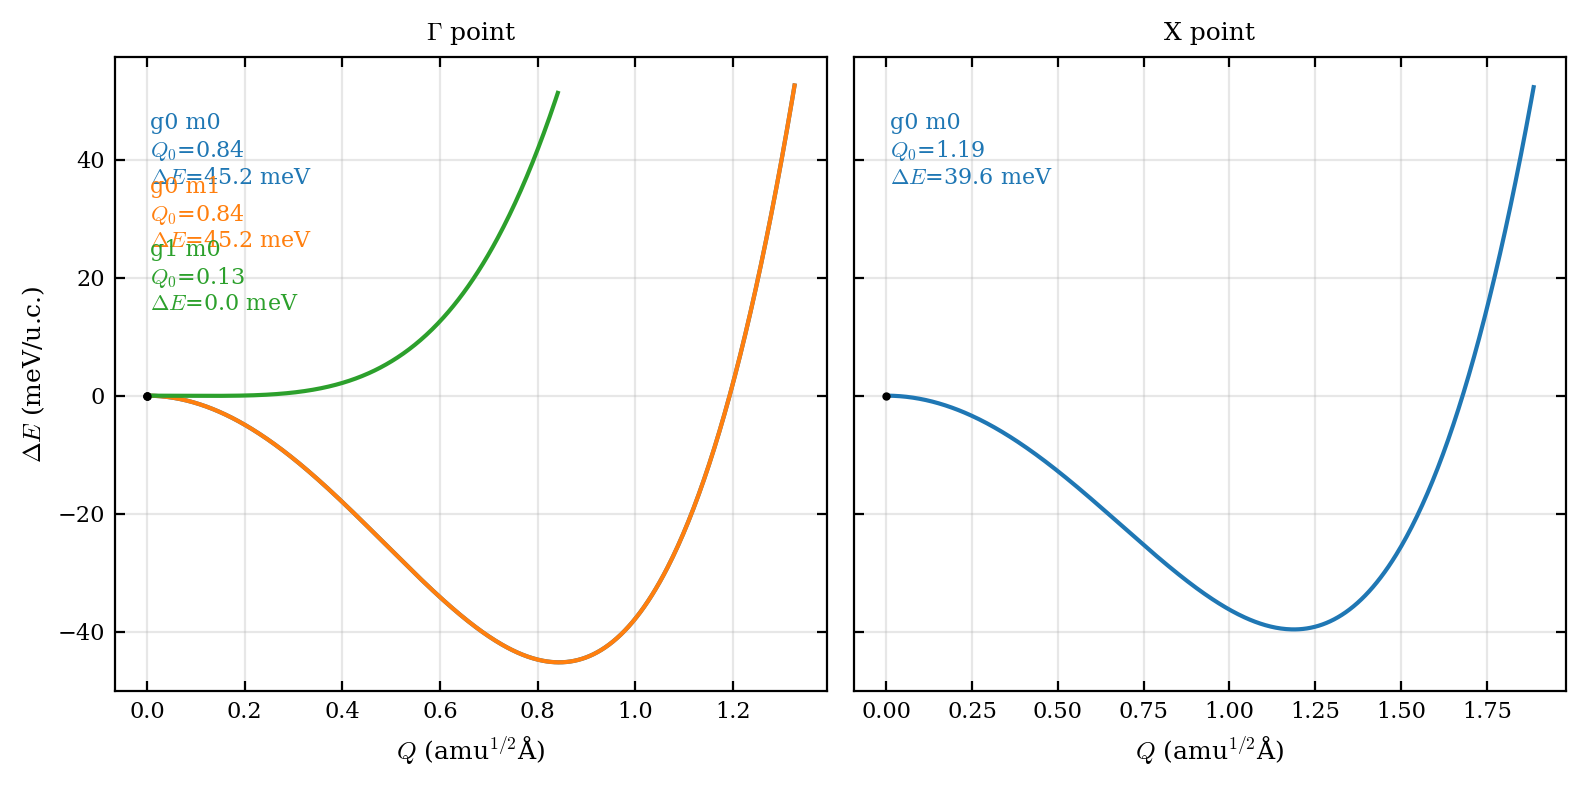

In [162]:
plot_frozen_phonons(results, mirror=False)

0


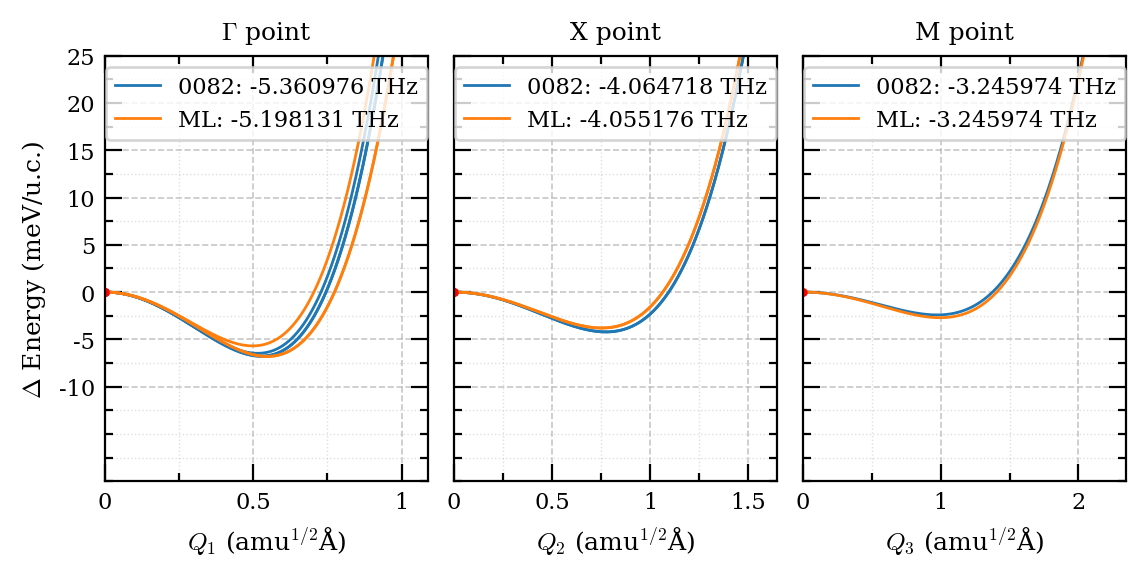

In [65]:
plotDWs('BaTiO3', ['0082', 'ML'])